In [1]:
%load_ext autoreload
%autoreload 2

# Load Imports

In [2]:
from __future__ import annotations
import os
import sys
import copy
import pandas as pd
import numpy as np
import logging
import random
import requests
import pyarrow.parquet as pq

from pathlib import Path, PurePath

# Configure logging
logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s [%(levelname)s] %(message)s")

# Suppress warnings
# logging.getLogger('safety_events').setLevel(logging.WARNING)

# Data quality profiling 
from ydata_profiling import ProfileReport

# Date and Time
import datetime
from datetime import datetime, timezone


# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.path import Path as MplPath
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "notebook_connected"

# Geo
from ipyleaflet import Map, Marker, MarkerCluster, basemaps
from ipywidgets import Dropdown, DatePicker, HBox, VBox, HTML, Output, Label, Layout

# Notebook Utilities
from IPython.display import display, Image, JSON
from tqdm import tqdm

# Duckdb
import duckdb


from typing import Sequence, Iterable, List, Optional, Tuple
from dataclasses import dataclass

# Preprocessing imports
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Baseline pipelines
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, max_error


import matplotlib.pyplot as plt

2026-01-26 05:30:22,581 [INFO] Pandas backend loaded 2.3.3
2026-01-26 05:30:22,594 [INFO] Numpy backend loaded 2.1.3
2026-01-26 05:30:22,603 [INFO] Pyspark backend loaded 4.0.1
2026-01-26 05:30:22,604 [INFO] Python backend loaded


In [2]:
# Manually set dir if things go awry
os.chdir('C:\\Users\\lover\\Documents\\GitHub\\predicting-safety-events-US-cities-base')

DATA_PATH = None
# Use explicit DATA_PATH, otherwise use relative dir to infer location
#DATA_PATH = PurePath('C:\\Users\\lover\\Documents\\GitHub\\Spotify_Listening_History_Analysis\\data')

# Get current path
cwd = PurePath(Path.cwd())

# Use conditional to ensure we do not traverse to higher level dir.
if not DATA_PATH:
    # Change current working directory from `notebooks` directory to one level above.
    os.chdir('..')    
    
    # Construct path to archive location
    DATA_PATH = cwd / 'data'
    
# Construct query output path
# QUERY_OUTPUT_PATH = cwd / 'data'/ 'sql' / 'query_results'

# Confirm location where data files are stored.
logging.info(str(DATA_PATH))

2026-01-18 15:01:06,571 [INFO] C:\Users\lover\Documents\GitHub\predicting-safety-events-US-cities-base\data


# Load Dataset

In [125]:
# Load parquet file into dataframe
sf_dataframe = pd.read_parquet(DATA_PATH / 'safety-SanFrancisco-2.parquet')
sf_dataframe.head()

,requestId,dataSubtype,dateTime,category,subcategory,status,address,latitude,longitude,source,neighborhood
0,1,911_Fire,2018-10-02 11:54:01,Potentially Life-Threatening,Medical Incident,NaN,ELM ST/FRANKLIN ST,37.781286,-122.422187,NaN,Tenderloin
1,2,311_All,2018-07-08 15:00:27,Street and Sidewalk Cleaning,Bulky Items,Closed,"1536 SACRAMENTO ST, SAN FRANCISCO, CA, 94109",37.791887,-122.418188,Mobile/Open311,Nob Hill
2,3,311_All,2016-06-28 13:12:28,General Request - COUNTY CLERK,customer_callback,Closed,Not associated with a specific address,0.000000,0.000000,Phone,Unknown
3,7,311_All,2017-03-03 09:34:49,Temporary Sign Request,Temporary Sign Request for Other_Event_Type,Closed,"2190 NORTH POINT ST, SAN FRANCISCO, CA, 94123",37.802853,-122.443245,Phone,Marina
4,10,911_Fire,2016-10-25 18:33:20,Potentially Life-Threatening,Medical Incident,NaN,200 Block of DALEWOOD WAY,37.737953,-122.456498,NaN,Portola


In [4]:
sf_dataframe.dtypes

requestId                int64
dataSubtype           category
dateTime        datetime64[ns]
category              category
subcategory           category
status                category
address                 object
latitude               float64
longitude              float64
source                category
neighborhood            object
dtype: object

# Data Preparation and Aggregation

In [126]:
sf_dataframe['category'].unique()

['Potentially Life-Threatening', 'Street and Sidewalk Cleaning', 'General Request - COUNTY CLERK', 'Temporary Sign Request', 'Fire', ..., 'General Request - CITY ATTORNEY', 'General Request - PUBLIC DEFENDER', 'General Request - ADULT PROBATION', 'General Request - GRANTS FOR THE ARTS', 'General Request - CONVENTION FACILITIES']
Length: 96
Categories (95, object): ['311 External Request', 'Abandoned Vehicle', 'Alarm', 'Blocked Street or SideWalk', ..., 'Street and Sidewalk Cleaning', 'Streetlights', 'Temporary Sign Request', 'Tree Maintenance']

There are 95 different categories!

> We will create one model per event category, starting with “Potentially Life-Threatening” events.


In [6]:
duckdb.sql("""
SELECT 
    category
    ,neighborhood
    ,COUNT(category) AS count
FROM sf_dataframe
GROUP BY
    category
    ,neighborhood
ORDER BY count DESC
LIMIT 5
""")

┌───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

In [7]:
duckdb.sql("""
SELECT 
    DISTINCT category
    ,COUNT(category) AS count
FROM sf_dataframe
WHERE category = 'Potentially Life-Threatening'
GROUP BY category
ORDER BY count DESC
LIMIT 5
""")

┌───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

In [127]:
pot_life_threatening = duckdb.sql("""
SELECT * 
FROM sf_dataframe
WHERE category = 'Potentially Life-Threatening'
AND dateTime BETWEEN '2016-01-01' AND '2020-01-01'
AND neighborhood IN 
('Mission', 'SoMa', 'Tenderloin', 'Nob Hill', 'Ingleside')
""").df()

pot_life_threatening.head(1)

,requestId,dataSubtype,dateTime,category,subcategory,status,address,latitude,longitude,source,neighborhood
0,1169551,911_Fire,2019-10-01 17:32:44,Potentially Life-Threatening,Medical Incident,NaN,MISSION ST/9TH ST,37.776231,-122.414711,NaN,SoMa


In [128]:
# Create 6-hour bins
# from datetime import datetime

# Source - https://stackoverflow.com/q/75815480
# Posted by coghlan, modified by community. See post 'Timeline' for change history
# Retrieved 2026-01-10, License - CC BY-SA 4.0

# df['DateTime'] = df['DateTime'].dt.floor('H')


interval_start = pot_life_threatening['dateTime'].dt.floor('6h')


In [129]:
interval_start

0        2019-10-01 12:00:00
1        2019-01-27 00:00:00
2        2017-10-04 12:00:00
3        2016-11-28 18:00:00
4        2019-11-22 12:00:00
                 ...        
135430   2016-01-31 12:00:00
135431   2016-01-02 06:00:00
135432   2016-12-18 00:00:00
135433   2019-12-22 12:00:00
135434   2017-10-16 18:00:00
Name: dateTime, Length: 135435, dtype: datetime64[ns]

In [130]:
# Create the GroupBy object. It has partitioned rows by neighborhood
# and 6-hour interval.
grouped_events = pot_life_threatening.groupby(['neighborhood', interval_start])

In [131]:
# Provide the aggregation we want for each group
counts = grouped_events.size()
counts

neighborhood  dateTime           
Ingleside     2016-01-01 00:00:00     3
              2016-01-01 18:00:00     6
              2016-01-02 00:00:00     2
              2016-01-02 06:00:00     1
              2016-01-02 12:00:00     3
                                     ..
Tenderloin    2019-12-30 18:00:00     8
              2019-12-31 00:00:00     2
              2019-12-31 06:00:00     9
              2019-12-31 12:00:00    10
              2019-12-31 18:00:00    14
Length: 27735, dtype: int64

In [132]:
# Create a clean dataframe with our target variable (count)
event_counts = (
    pot_life_threatening
        .assign(interval_start=pot_life_threatening["dateTime"].dt.floor("6h"))
        .groupby(["neighborhood", "interval_start"], as_index=False)
        .size()
        .rename(columns={"size": "count"})
)

event_counts.head(5)

,neighborhood,interval_start,count
0,Ingleside,2016-01-01 00:00:00,3
1,Ingleside,2016-01-01 18:00:00,6
2,Ingleside,2016-01-02 00:00:00,2
3,Ingleside,2016-01-02 06:00:00,1
4,Ingleside,2016-01-02 12:00:00,3


In [133]:
# Sanity check our event counts.
# Should have a min >= 0, 
# mostly small ints
# right-skewed (many low-count bins, few high ones) 
event_counts['count'].describe()

count    27735.000000
mean         4.883180
std          3.139732
min          1.000000
25%          2.000000
50%          4.000000
75%          7.000000
max         29.000000
Name: count, dtype: float64

<Axes: ylabel='Frequency'>

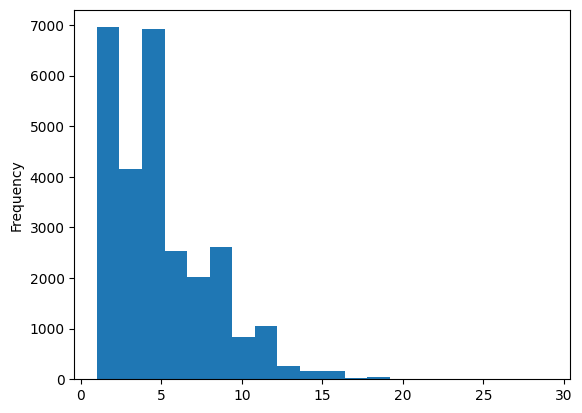

In [134]:
# Sanity check our event counts.
# Should have a min >= 0, 
# mostly small ints
# right-skewed (many low-count bins, few high ones) 
event_counts['count'].plot.hist(bins=20)

In [16]:
len(event_counts)

27735

In [135]:
def reindex_complete_6h_grid(
    event_counts: pd.DataFrame,
    *,
    neighborhoods: Sequence[str],
    start: str | pd.Timestamp,
    end: str | pd.Timestamp,  # exclusive end
    freq: str = "6H",
) -> pd.DataFrame:
    """
    Ensure every neighborhood has a complete 6-hour time grid in [start, end),
    filling missing intervals with count=0.

    Parameters
    ----------
    event_counts:
        DataFrame with columns: neighborhood, interval_start, count
    neighborhoods:
        Neighborhoods to include (and order to use).
    start, end:
        Time bounds: [start, end) (end is exclusive).
    freq:
        Frequency string, default "6H".

    Returns
    -------
    pd.DataFrame
        Columns: neighborhood, interval_start, count
        with complete grid and missing counts filled with 0.
    """
    required = {"neighborhood", "interval_start", "count"}
    missing = required - set(event_counts.columns)
    if missing:
        raise ValueError(f"event_counts missing required columns: {missing}")

    df = event_counts.copy()

    # Normalize dtypes
    df["interval_start"] = pd.to_datetime(df["interval_start"], errors="coerce")
    df["count"] = df["count"].fillna(0).astype("int64")

    # Build the complete 6-hour time index for the requested window
    start_ts = pd.Timestamp(start).floor(freq)
    end_ts = pd.Timestamp(end)

    full_range = pd.date_range(start=start_ts, end=end_ts, freq=freq)
    full_range = full_range[full_range < end_ts]  # enforce [start, end)

    # Build MultiIndex of all neighborhood × interval_start combos
    # Use Categorical so neighborhoods stay in your desired order
    neighborhoods_cat = pd.Categorical(neighborhoods, categories=list(neighborhoods), ordered=False)

    full_index = pd.MultiIndex.from_product(
        [neighborhoods_cat, full_range],
        names=["neighborhood", "interval_start"],
    )

    # Reindex onto the full grid and fill missing counts with 0
    out = (
        df.set_index(["neighborhood", "interval_start"])
          .reindex(full_index, fill_value=0)
          .reset_index()
          .sort_values(["neighborhood", "interval_start"], kind="stable")
          .reset_index(drop=True)
    )

    out["neighborhood"] = out["neighborhood"].astype("category")
    out["count"] = out["count"].astype("int64")

    return out

In [136]:
neighborhoods = ["Mission", "SoMa", "Tenderloin", "Nob Hill", "Ingleside"]

event_counts_full = reindex_complete_6h_grid(
    event_counts,
    neighborhoods=neighborhoods,
    start="2016-01-01",
    end="2020-01-01",   # exclusive
    freq="6h",
)

event_counts_full.head(5)

,neighborhood,interval_start,count
0,Mission,2016-01-01 00:00:00,10
1,Mission,2016-01-01 06:00:00,2
2,Mission,2016-01-01 12:00:00,1
3,Mission,2016-01-01 18:00:00,3
4,Mission,2016-01-02 00:00:00,4


# Feature Engineering

In [138]:
@dataclass(frozen=True)
class TimeFeatureConfig:
    """Config for cyclical encodings."""
    dow_period: int = 7
    hour_period: int = 24


def add_time_features(
    df: pd.DataFrame,
    *,
    ts_col: str = "interval_start",
    config: TimeFeatureConfig = TimeFeatureConfig(),
) -> pd.DataFrame:
    """
    Add basic datetime features + cyclical encodings derived from `ts_col`.

    Adds:
      - year, month, day, dow (0=Mon..6=Sun), hour (0/6/12/18)
      - dow_sin, dow_cos
      - hour_sin, hour_cos
    """
    if ts_col not in df.columns:
        raise ValueError(f"Missing required timestamp column: {ts_col}")

    out = df.copy()
    out[ts_col] = pd.to_datetime(out[ts_col], errors="coerce")

    # Basic parts
    out["year"] = out[ts_col].dt.year.astype("int32")
    out["month"] = out[ts_col].dt.month.astype("int8")
    out["day"] = out[ts_col].dt.day.astype("int8")
    out["dow"] = out[ts_col].dt.dayofweek.astype("int8")  # 0=Mon ... 6=Sun
    out["hour"] = out[ts_col].dt.hour.astype("int8")      # should be 0,6,12,18

    # Cyclical encodings
    # Convert to radians: 2π * value / period
    dow_rad = 2.0 * np.pi * (out["dow"].to_numpy() / config.dow_period)
    hour_rad = 2.0 * np.pi * (out["hour"].to_numpy() / config.hour_period)

    out["dow_sin"] = np.sin(dow_rad)
    out["dow_cos"] = np.cos(dow_rad)
    out["hour_sin"] = np.sin(hour_rad)
    out["hour_cos"] = np.cos(hour_rad)

    return out


In [139]:
# Add time features to our dataframe
# event_counts_full columns: neighborhood, interval_start, count
feat_df = add_time_features(event_counts_full)

feat_df[["neighborhood", "interval_start", "year", "month", "day", "dow", "hour", "dow_sin", "dow_cos", "hour_sin", "hour_cos", "count"]].head()


,neighborhood,interval_start,year,month,day,dow,hour,dow_sin,dow_cos,hour_sin,hour_cos,count
0,Mission,2016-01-01 00:00:00,2016,1,1,4,0,-0.433884,-0.900969,0.000000e+00,1.000000e+00,10
1,Mission,2016-01-01 06:00:00,2016,1,1,4,6,-0.433884,-0.900969,1.000000e+00,6.123234e-17,2
2,Mission,2016-01-01 12:00:00,2016,1,1,4,12,-0.433884,-0.900969,1.224647e-16,-1.000000e+00,1
3,Mission,2016-01-01 18:00:00,2016,1,1,4,18,-0.433884,-0.900969,-1.000000e+00,-1.836970e-16,3
4,Mission,2016-01-02 00:00:00,2016,1,2,5,0,-0.974928,-0.222521,0.000000e+00,1.000000e+00,4


In [21]:
# Complete event dataframe
%store feat_df

Stored 'feat_df' (DataFrame)


In [140]:
feat_df.columns

Index(['neighborhood', 'interval_start', 'count', 'year', 'month', 'day',
       'dow', 'hour', 'dow_sin', 'dow_cos', 'hour_sin', 'hour_cos'],
      dtype='object')

# Preprocessing: ColumnTransformer (OHE Neighborhood + Scale Numeric)

In [141]:
def make_preprocessor(
    *,
    categorical_features: List[str],
    numeric_features: List[str],
    scale_numeric: bool = True,
    ohe_drop: Optional[str] = None,  # e.g. "first" or None
) -> ColumnTransformer:
    """
    Build a ColumnTransformer that:
      - OneHotEncodes categorical features (neighborhood)
      - Optionally scales numeric features (for linear models)
    """
    cat = OneHotEncoder(
        drop=ohe_drop,
        handle_unknown="ignore",
        sparse_output=False,  # sklearn >=1.2
    )

    num = StandardScaler() if scale_numeric else "passthrough"

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", cat, categorical_features),
            ("num", num, numeric_features),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return preprocessor

In [142]:
# Define feature columns
BASE_CATEGORICAL = ["neighborhood"]
BASE_NUMERIC = ["year", "month", "day", "dow_sin", "dow_cos", "hour_sin", "hour_cos"]
TARGET_COL = "count"

# Build Baseline Pipelines (Ridge + HGBR)

In [144]:
def make_ridge_pipeline(
    *,
    ohe_drop: Optional[str] = None,
    alpha: float = 1.0,
    random_state: int = 42,
) -> Pipeline:
    """
    Ridge baseline: OHE + StandardScaler + Ridge.
    """
    pre = make_preprocessor(
        categorical_features=BASE_CATEGORICAL,
        numeric_features=BASE_NUMERIC,
        scale_numeric=True,
        ohe_drop=ohe_drop,
    )

    model = Ridge(alpha=alpha, random_state=random_state)

    return Pipeline(steps=[
        ("preprocess", pre),
        ("model", model),
    ])

In [145]:
def make_hgbr_pipeline(
    *,
    ohe_drop: Optional[str] = None,
    random_state: int = 42,
) -> Pipeline:
    """
    Gradient boosting baseline: OHE + passthrough numeric (no scaling) + HGBR.
    """
    pre = make_preprocessor(
        categorical_features=BASE_CATEGORICAL,
        numeric_features=BASE_NUMERIC,
        scale_numeric=False,
        ohe_drop=ohe_drop,
    )

    model = HistGradientBoostingRegressor(random_state=random_state)

    return Pipeline(steps=[
        ("preprocess", pre),
        ("model", model),
    ])


In [146]:
# Prepary X / y 

# X / y
X = feat_df[BASE_CATEGORICAL + BASE_NUMERIC].copy()
y = feat_df[TARGET_COL].astype("int64")


In [147]:
# Sanity checks
# Check bins are only the expected hours
feat_df["hour"].value_counts().sort_index()

hour
0     7305
6     7305
12    7305
18    7305
Name: count, dtype: int64

In [148]:
# Check dow range
feat_df["dow"].min(), feat_df["dow"].max()

(np.int8(0), np.int8(6))

In [149]:
# Check no NA in features
X.isna().sum()

neighborhood    0
year            0
month           0
day             0
dow_sin         0
dow_cos         0
hour_sin        0
hour_cos        0
dtype: int64

# Store Variables

In [214]:
%store feat_df event_counts_full

Stored 'feat_df' (DataFrame)
Stored 'event_counts_full' (DataFrame)


In [215]:
# Retrieve all dataframes
# %store -r feat_df
%store -r feat_df event_counts_full
#%store -r events_counts_full

In [150]:
# Define feature columns
BASE_CATEGORICAL = ["neighborhood"]
BASE_NUMERIC = ["year", "month", "day", "dow_sin", "dow_cos", "hour_sin", "hour_cos"]
TARGET_COL = "count"

In [13]:
dir()

['BASE_CATEGORICAL',
 'BASE_NUMERIC',
 'ColumnTransformer',
 'DatePicker',
 'Dropdown',
 'DummyRegressor',
 'HBox',
 'HTML',
 'HistGradientBoostingRegressor',
 'Image',
 'In',
 'Iterable',
 'JSON',
 'Label',
 'Layout',
 'List',
 'Map',
 'Marker',
 'MarkerCluster',
 'MplPath',
 'OneHotEncoder',
 'Optional',
 'Out',
 'Output',
 'Path',
 'Pipeline',
 'ProfileReport',
 'PurePath',
 'Ridge',
 'Sequence',
 'StandardScaler',
 'TARGET_COL',
 'TEST_FRACTION',
 'Tuple',
 'VBox',
 '_',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__session__',
 '__spec__',
 '_dh',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i2',
 '_i3',
 '_i4',
 '_i5',
 '_i6',
 '_i7',
 '_i8',
 '_i9',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'annotations',
 'basemaps',
 'copy',
 'dataclass',
 'datetime',
 'display',
 'duckdb',
 'event_counts_full',
 'exit',
 'feat_df',
 'get_ipython',
 'go',
 'logging',
 'max_error',
 'mean_absolute_error',
 'mean_squared_error',
 'mt

In [14]:
to_delete = [
 'air_duels',
 'annotations',
 'basemaps',
 'calcareers_resume',
 'copy',
 'dataclass',
 'datetime',
 'display',
 'duckdb',
 'duels',
 'efficency_df',
 'efficiency_df',
 'euro_2024_matches',
 'euro_2024_wingers',
 'exit',
 'final_third',
 'final_third_passes',
 'gakp',
 'get_ipython',
 'go',
 'logging',
 'max_error',
 'mean_absolute_error',
 'mean_squared_error',
 'minutes',
 'mticker',
 'my_inferred_feature_cols',
 'nico_p90_results',
 'nico_williams_events',
 'np',
 'npxg',
 'nw_pass_length',
 'open',
 'os',
 'params',
 'pd',
 'percentiles',
 'pio',
 'players_df',
 'plt',
 'pq',
 'px',
 'quit',
 'random',
 'requests',
 'salah_row',
 'smart_passes',
 'sns',
 'spain_lineups_df',
 'spain_matches',
 'spain_matches_info',
 'summary',
 'summary_per_90',
 'tqdm',
 'train',
 'values',
 'volume_per_90_df',
 'winger_ids_df']

In [15]:
# Source - https://stackoverflow.com/a/64594787
# Posted by go2nirvana
# Retrieved 2026-01-11, License - CC BY-SA 4.0

# to_delete = ['i', 'myvar']
# for _var in to_delete:
#     if _var in locals() or _var in globals():
#         exec(f'del {_var}')


In [151]:
feat_df.head(1)

,neighborhood,interval_start,count,year,month,day,dow,hour,dow_sin,dow_cos,hour_sin,hour_cos
0,Mission,2016-01-01,10,2016,1,1,4,0,-0.433884,-0.900969,0.0,1.0


# Time Aware Test/Train Split

At this point we have:

* event_counts_full
    * columns: neighborhood, interval_start, count
* feat_df = add_time_features(event_counts_full)
* Feature columns already defined
* Target column: count

We will **not**:

* stratify
* shuffle
* group by neighborhood
* use sklearn’s train_test_split

We will do this manually.
1. Sort everything by time
2. Take earliest **85%** of timestamps --> training
3. Take latest **15%** of timestamps --> test
4. Test data must be _strictly later in time_ that training data.

In [152]:
# Sort by time
feat_df = feat_df.sort_values("interval_start").reset_index(drop=True)

In [153]:
# Compute the split point by index
TEST_FRACTION = 0.15

n_samples = len(feat_df)
split_idx = int(n_samples * (1 - TEST_FRACTION))


In [154]:
# Split X and y

X = feat_df[BASE_CATEGORICAL + BASE_NUMERIC]
y = feat_df["count"]

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

In [155]:
X_train.columns

Index(['neighborhood', 'year', 'month', 'day', 'dow_sin', 'dow_cos',
       'hour_sin', 'hour_cos'],
      dtype='object')

In [156]:
# Sanity check time ordering
feat_df["interval_start"].max(), feat_df["interval_start"].min()

(Timestamp('2019-12-31 18:00:00'), Timestamp('2016-01-01 00:00:00'))

In [157]:
# Neighborhood presence. All neighborhoods should be present.
X_train["neighborhood"].value_counts()
X_test["neighborhood"].value_counts()

neighborhood
Mission       877
SoMa          877
Ingleside     877
Tenderloin    876
Nob Hill      876
Name: count, dtype: int64

We do not split per neighborhood, as the model learns neighborhoods as a feature. We want temporal generalization, not neighborhood isolation.

# Why we need DummyRegressor

We predicting counts, per 6-hour bin, per neighborhood. Counts have:
* Central tendency (average level)
* Big variance by neighborhood and time

Mode can look good, but just basically guess something near average. `DummyRegressor` gives performance of that exact behavior.

* If Ridge/HBR barely beats DummyRegressor:
    * Features/model are not learning much signal, or we are over-regularized, or you have leakage elsewhere.
* If Ridge / HGBR clearly beats DummyRegressor:
    * Model is extracting useful predictive structure.
 
* RMSE / MAE
    * Set the "floor." Your model must reduce RMSE/MAE relative to dummy, or it not worth it.
 
Mean is the correct dummy since we want to "predict the typical count."

We must fit `DummyRegressor` on TRAIN only to prevent leakage. Fit on `y_train` and evaluate on `y_test`.

The "precision" takeaway is that `DummyRegressor` is a control group. 
* **Control**: predict the mean always (DummyRegressor)
* **Treatment**: your ML model (Ridge / HGBR)

In [158]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)          # X_train is ignored, but required by API
y_pred_train = dummy.predict(X_train)
y_pred_test  = dummy.predict(X_test)

In [159]:
def regression_metrics(
    y_true: np.ndarray | pd.Series,
    y_pred: np.ndarray,
) -> dict[str, float]:
    """
    Compute regression metrics used in the assignment.
    """
    return {
        "RMSE": mean_squared_error(y_true, y_pred, multioutput='raw_values'),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MaxError": max_error(y_true, y_pred),
    }


In [ ]:
mean_squared_error?

In [160]:
# Evaluate metrics
dummy_train_metrics = regression_metrics(y_train, y_pred_train)
dummy_test_metrics  = regression_metrics(y_test, y_pred_test)

dummy_train_metrics, dummy_test_metrics


({'RMSE': array([10.06294864]),
  'MAE': 2.517600949761475,
  'MaxError': 19.437250875709626},
 {'RMSE': array([13.05715407]),
  'MAE': 2.7677905804848297,
  'MaxError': 24.437250875709626})

In [161]:
# Sanity check what dummy predicts
dummy.constant_

array([[4.56274912]])

In [162]:
# ...`dummy.constant_` should equal y_train.mean()
y_train.mean()

np.float64(4.562749124290373)

# Ridge Regressor

In [163]:
# ----------------------------
# Ridge pipeline
# ----------------------------
# Preprocessor: OHE for neighborhood, scale numeric for Ridge
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", drop=None, sparse_output=False), BASE_CATEGORICAL),
        ("num", StandardScaler(), BASE_NUMERIC),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

ridge = Ridge(alpha=1.0, random_state=42)

ridge_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", ridge),
])


# ----------------------------
# Fit + predict
# ----------------------------
ridge_pipe.fit(X_train, y_train)

y_train_pred_ridge = ridge_pipe.predict(X_train)
y_test_pred_ridge  = ridge_pipe.predict(X_test)


# ----------------------------
# Evaluate
# ----------------------------
ridge_train_metrics = regression_metrics(y_train, y_train_pred_ridge)
ridge_test_metrics  = regression_metrics(y_test, y_test_pred_ridge)

ridge_train_metrics, ridge_test_metrics


({'RMSE': array([5.45464911]),
  'MAE': 1.8017087150401707,
  'MaxError': 15.816258424819347},
 {'RMSE': array([6.5965887]),
  'MAE': 1.8889425206844308,
  'MaxError': 20.7217611521854})

In [164]:
# Assumes you already computed these from the DummyRegressor step:
# dummy_train_metrics, dummy_test_metrics

results = pd.DataFrame(
    [
        {
            "Model": "DummyRegressor (mean)",
            "Train RMSE": dummy_train_metrics["RMSE"],
            "Test RMSE": dummy_test_metrics["RMSE"],
            "Train MAE": dummy_train_metrics["MAE"],
            "Test MAE": dummy_test_metrics["MAE"],
            "Train MaxError": dummy_train_metrics["MaxError"],
            "Test MaxError": dummy_test_metrics["MaxError"],
        },
        {
            "Model": "Ridge",
            "Train RMSE": ridge_train_metrics["RMSE"],
            "Test RMSE": ridge_test_metrics["RMSE"],
            "Train MAE": ridge_train_metrics["MAE"],
            "Test MAE": ridge_test_metrics["MAE"],
            "Train MaxError": ridge_train_metrics["MaxError"],
            "Test MaxError": ridge_test_metrics["MaxError"],
        },
    ]
).set_index("Model")

results


,Train RMSE,Test RMSE,Train MAE,Test MAE,Train MaxError,Test MaxError
Model,,,,,,
DummyRegressor (mean),[10.062948644755545],[13.057154069017656],2.517601,2.767791,19.437251,24.437251
Ridge,[5.454649114661952],[6.596588700064784],1.801709,1.888943,15.816258,20.721761


In [165]:
# Reconstruct the rows corresponding to X_test, including interval_start
# This works even if X_test does not contain interval_start.
test_rows = feat_df.loc[X_test.index, ["interval_start", "neighborhood", "count"]].copy()

# Attach predictions with explicit index alignment
test_rows["pred_ridge"] = pd.Series(np.asarray(y_test_pred_ridge), index=X_test.index)

#  Show a few chronological examples
test_rows = test_rows.sort_values("interval_start")
test_rows.head(15)

,interval_start,neighborhood,count,pred_ridge
24837,2019-05-26 18:00:00,Ingleside,3,2.257002
24838,2019-05-26 18:00:00,Mission,4,3.780552
24839,2019-05-26 18:00:00,SoMa,11,6.628379
24840,2019-05-27 00:00:00,Tenderloin,7,4.940664
24841,2019-05-27 00:00:00,Mission,2,1.840398
24842,2019-05-27 00:00:00,SoMa,2,4.688224
24843,2019-05-27 00:00:00,Ingleside,0,0.316848
24844,2019-05-27 00:00:00,Nob Hill,5,2.013113
24845,2019-05-27 06:00:00,Mission,2,3.292863
24846,2019-05-27 06:00:00,Ingleside,3,1.769312


In [166]:
y_test_pred_ridge

array([2.2570017 , 3.78055243, 6.62837851, ..., 3.66091187, 6.7611774 ,
       2.13736114])

In [167]:
def build_pred_frame(
    feat_df: pd.DataFrame,
    X_index: pd.Index,
    y_true: pd.Series,
    y_pred: np.ndarray | pd.Series,
    *,
    y_col: str = "count",
    pred_col: str = "pred",
) -> pd.DataFrame:
    """
    Return a tidy frame with interval_start, neighborhood, y_true, y_pred aligned by index.
    """
    out = feat_df.loc[X_index, ["interval_start", "neighborhood", y_col]].copy()
    out = out.rename(columns={y_col: "y_true"})
    out[pred_col] = pd.Series(np.asarray(y_pred), index=X_index)
    return out.sort_values(["neighborhood", "interval_start"], kind="stable").reset_index(drop=True)


test_preds = build_pred_frame(
    feat_df=feat_df,
    X_index=X_test.index,
    y_true=y_test,
    y_pred=y_test_pred_ridge,
    pred_col="y_pred",
)

# Last ~30 intervals PER neighborhood
last30_per_neighborhood = (
    test_preds.sort_values("interval_start")
              .groupby("neighborhood", as_index=False, observed=True)
              .tail(30)
              .sort_values(["neighborhood", "interval_start"])
)

last30_per_neighborhood


,interval_start,neighborhood,y_true,y_pred
847,2019-12-24 12:00:00,Mission,5,5.198694
848,2019-12-24 18:00:00,Mission,3,3.746229
849,2019-12-25 00:00:00,Mission,1,1.916051
850,2019-12-25 06:00:00,Mission,4,3.368515
851,2019-12-25 12:00:00,Mission,5,5.256979
...,...,...,...,...
4378,2019-12-30 18:00:00,Ingleside,1,2.124712
4379,2019-12-31 00:00:00,Ingleside,1,0.248897
4380,2019-12-31 06:00:00,Ingleside,3,1.701362
4381,2019-12-31 12:00:00,Ingleside,3,3.589826


## Scatterplot Actual vs. Predicted

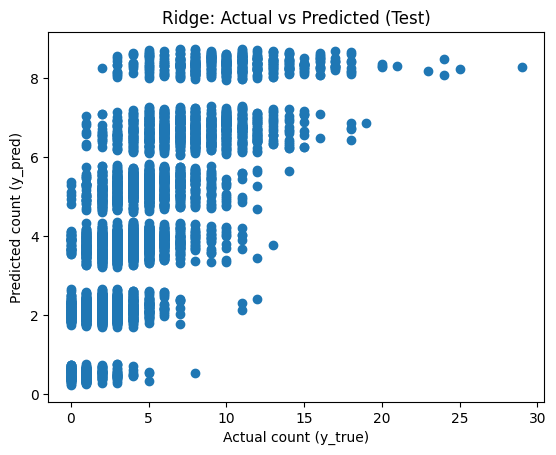

In [168]:
plt.figure()
plt.scatter(test_preds["y_true"], test_preds["y_pred"])
plt.xlabel("Actual count (y_true)")
plt.ylabel("Predicted count (y_pred)")
plt.title("Ridge: Actual vs Predicted (Test)")
plt.show()


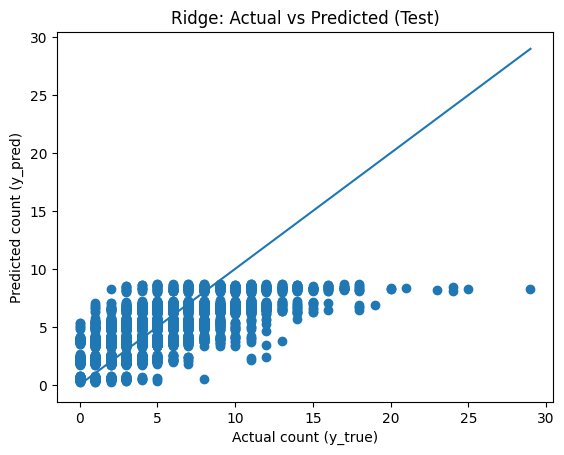

In [169]:
plt.figure()
plt.scatter(test_preds["y_true"], test_preds["y_pred"])
m = min(test_preds["y_true"].min(), test_preds["y_pred"].min())
M = max(test_preds["y_true"].max(), test_preds["y_pred"].max())
plt.plot([m, M], [m, M])  # diagonal reference
plt.xlabel("Actual count (y_true)")
plt.ylabel("Predicted count (y_pred)")
plt.title("Ridge: Actual vs Predicted (Test)")
plt.show()


## Residuals Over Time (Test Set)

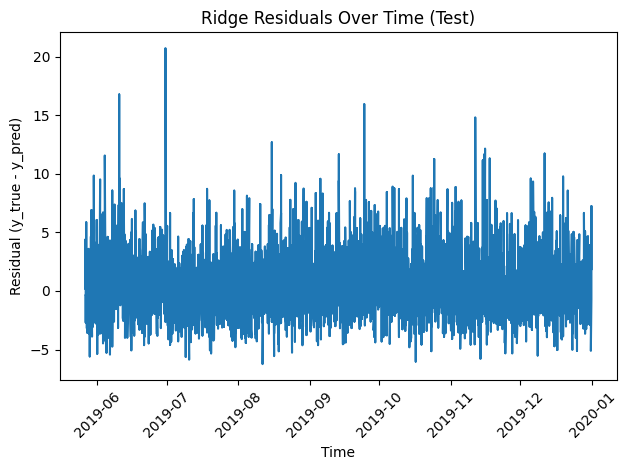

In [170]:
test_preds_time = test_preds.sort_values("interval_start").copy()
test_preds_time["residual"] = test_preds_time["y_true"] - test_preds_time["y_pred"]

plt.figure()
plt.plot(test_preds_time["interval_start"], test_preds_time["residual"])
plt.xlabel("Time")
plt.ylabel("Residual (y_true - y_pred)")
plt.title("Ridge Residuals Over Time (Test)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


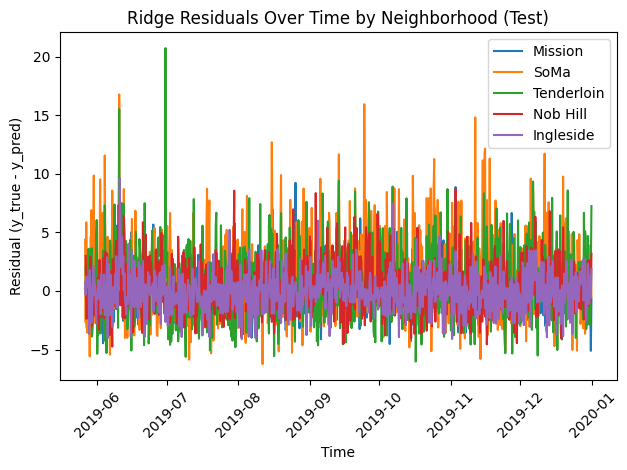

In [171]:
# Per neighborhood
plt.figure()
for nbhd, g in test_preds_time.groupby("neighborhood", observed=True):
    plt.plot(g["interval_start"], g["residual"], label=str(nbhd))
plt.xlabel("Time")
plt.ylabel("Residual (y_true - y_pred)")
plt.title("Ridge Residuals Over Time by Neighborhood (Test)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## Over/Underfitting Check

In [172]:
rows = [
    {
        "Model": "Ridge",
        "Train RMSE": ridge_train_metrics["RMSE"],
        "Test RMSE": ridge_test_metrics["RMSE"],
        "Train MAE": ridge_train_metrics["MAE"],
        "Test MAE": ridge_test_metrics["MAE"],
        "Train MaxError": ridge_train_metrics["MaxError"],
        "Test MaxError": ridge_test_metrics["MaxError"],
    }
]

# Add dummy row if you have it
if "dummy_train_metrics" in globals() and "dummy_test_metrics" in globals():
    rows.insert(0, {
        "Model": "DummyRegressor (mean)",
        "Train RMSE": dummy_train_metrics["RMSE"],
        "Test RMSE": dummy_test_metrics["RMSE"],
        "Train MAE": dummy_train_metrics["MAE"],
        "Test MAE": dummy_test_metrics["MAE"],
        "Train MaxError": dummy_train_metrics["MaxError"],
        "Test MaxError": dummy_test_metrics["MaxError"],
    })

pd.DataFrame(rows).set_index("Model")


,Train RMSE,Test RMSE,Train MAE,Test MAE,Train MaxError,Test MaxError
Model,,,,,,
DummyRegressor (mean),[10.062948644755545],[13.057154069017656],2.517601,2.767791,19.437251,24.437251
Ridge,[5.454649114661952],[6.596588700064784],1.801709,1.888943,15.816258,20.721761


Interpreting results

* Dummy Test RMSE = 13.06, Ridge Test RMSE = 6.60 --> 50% reduction in RMSE
* Dummy Test MAE = 2.77, Ridge Test MAE = 1.89 --> 32% reduction in typical absolute error. Ridge is learning structure
* Overfitting = (Test RMSE - Train RMSE )/ Train RMSE --> 1.15 / 5.45 ~ 21%.
* MAE ~ 1.9 --> On average, we are off by ~2 events per 6-hour window.
    * If counts are 1-3, this is large
    * If counts are 5-15, this is moderat
    * If counts are 20-40, this is small
* Large MaxError indicates there is a bin where we missed by ~ 21 events.
    * Linear models smooth
    * Emergency spikes are nonlinear
    * Rare surges dominate max error.
    * Why assignment suggests using "more powerful ML models."  

In [173]:
feat_df['count'].describe()

count    29220.000000
mean         4.635010
std          3.241484
min          0.000000
25%          2.000000
50%          4.000000
75%          6.000000
max         29.000000
Name: count, dtype: float64

## Test Importance

In [174]:
from city_events_ml.io import TargetSpec, build_target_table
from city_events_ml.features import add_time_features
from city_events_ml.pipelines import (
    FeatureSpec,
    make_dummy_pipeline,
    make_ridge_pipeline,
    make_hgbr_pipeline,
    make_poisson_pipeline,
)
from city_events_ml.evaluation import (
    MetricsStore,
    evaluate_model,
    get_feature_names,
    linear_feature_importance,
    hgbr_permutation_importance,
    plot_feature_importance,
)
from city_events_ml.serialization import save_model_skops

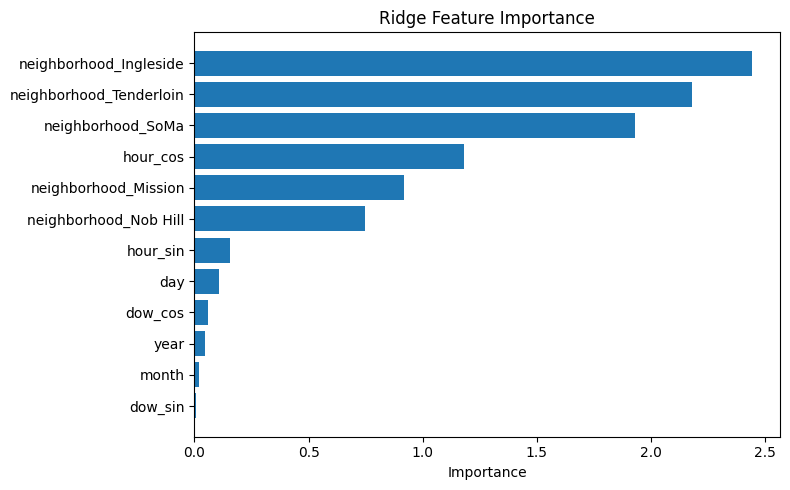

In [175]:
ridge_imp = linear_feature_importance(ridge_pipe)
plot_feature_importance(ridge_imp, "importance", "Ridge Feature Importance")

# HistGradientBoosting Regressor

In [184]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, max_error
from sklearn.inspection import permutation_importance

In [185]:
# ----------------------------
# Metrics helpers
# ----------------------------
def rmse(y_true: np.ndarray | pd.Series, y_pred: np.ndarray) -> float:
    return mean_squared_error(y_true, y_pred, )

def mae(y_true: np.ndarray | pd.Series, y_pred: np.ndarray) -> float:
    return mean_absolute_error(y_true, y_pred)

def maxerr(y_true: np.ndarray | pd.Series, y_pred: np.ndarray) -> float:
    return max_error(y_true, y_pred)

def evaluate_regression(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    return {"RMSE": rmse(y_true, y_pred), "MAE": mae(y_true, y_pred), "MaxError": maxerr(y_true, y_pred)}



In [186]:
preprocess_hgbr = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", drop=None, sparse_output=False), BASE_CATEGORICAL),
        ("num", "passthrough", BASE_NUMERIC),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

hgbr = HistGradientBoostingRegressor(
    random_state=42,
    loss="squared_error",
)

hgbr_pipe = Pipeline(steps=[
    ("preprocess", preprocess_hgbr),
    ("model", hgbr),
])


# ----------------------------
# Time-series CV setup
# ----------------------------
tscv = TimeSeriesSplit(n_splits=5)


# ----------------------------
# Fast randomized hyperparam search
# ----------------------------
param_distributions = {
    "model__learning_rate": [0.03, 0.05, 0.08, 0.1, 0.15],
    "model__max_depth": [None, 3, 5, 7, 9],
    "model__max_leaf_nodes": [15, 31, 63, 127],
    "model__min_samples_leaf": [10, 20, 50, 100],
    "model__l2_regularization": [0.0, 0.01, 0.1, 1.0],
}

search = RandomizedSearchCV(
    estimator=hgbr_pipe,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="neg_root_mean_squared_error",  # RMSE (lower is better)
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

search.fit(X_train, y_train)

best_hgbr_pipe = search.best_estimator_
best_params = search.best_params_
best_cv_rmse = -search.best_score_

best_params, best_cv_rmse

Fitting 5 folds for each of 20 candidates, totalling 100 fits


({'model__min_samples_leaf': 20,
  'model__max_leaf_nodes': 15,
  'model__max_depth': 9,
  'model__learning_rate': 0.03,
  'model__l2_regularization': 0.0},
 np.float64(2.269651626434992))

In [187]:
# ----------------------------
# CV summary: mean ± std for RMSE + MAE
# ----------------------------
cv_results = pd.DataFrame(search.cv_results_)

# RMSE from scoring (neg_root_mean_squared_error)
rmse_mean = -cv_results.loc[cv_results["rank_test_score"] == 1, "mean_test_score"].iloc[0]
rmse_std  =  cv_results.loc[cv_results["rank_test_score"] == 1, "std_test_score"].iloc[0]

# Compute MAE across folds using cross-val predictions is more work;
# simplest: refit best model per fold manually.
def cv_mae_for_best_model(
    model: Pipeline,
    X: pd.DataFrame,
    y: pd.Series,
    splitter: TimeSeriesSplit,
) -> tuple[float, float]:
    maes: list[float] = []
    for train_idx, val_idx in splitter.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        m = model
        m.fit(X_tr, y_tr)
        pred = m.predict(X_val)
        maes.append(mean_absolute_error(y_val, pred))
    return float(np.mean(maes)), float(np.std(maes))

best_model_for_cv = best_hgbr_pipe
mae_mean, mae_std = cv_mae_for_best_model(best_model_for_cv, X_train, y_train, tscv)

cv_summary = pd.DataFrame(
    {
        "Metric": ["RMSE", "MAE"],
        "CV Mean": [rmse_mean, mae_mean],
        "CV Std": [rmse_std, mae_std],
    }
)

cv_summary


,Metric,CV Mean,CV Std
0,RMSE,2.269652,0.036074
1,MAE,1.749785,0.014545


In [188]:
# ----------------------------
# Final fit on full train, eval on train/test
# ----------------------------
best_hgbr_pipe.fit(X_train, y_train)

y_train_pred_hgbr = best_hgbr_pipe.predict(X_train)
y_test_pred_hgbr  = best_hgbr_pipe.predict(X_test)

hgbr_train_metrics = evaluate_regression(y_train, y_train_pred_hgbr)
hgbr_test_metrics  = evaluate_regression(y_test, y_test_pred_hgbr)

hgbr_train_metrics, hgbr_test_metrics


({'RMSE': 4.982262908608332,
  'MAE': 1.724208277943284,
  'MaxError': 16.239355026020824},
 {'RMSE': 6.222853815760959,
  'MAE': 1.8369427221214698,
  'MaxError': 21.230866249347258})

In [189]:
# ----------------------------
# Add to your comparison table (Dummy / Ridge / HGBR)
# Assumes you already have dummy_* and ridge_* metrics from Phase 4.
# ----------------------------
rows = []

if "dummy_train_metrics" in globals() and "dummy_test_metrics" in globals():
    rows.append({
        "Model": "DummyRegressor (mean)",
        "Train RMSE": dummy_train_metrics["RMSE"],
        "Test RMSE": dummy_test_metrics["RMSE"],
        "Train MAE": dummy_train_metrics["MAE"],
        "Test MAE": dummy_test_metrics["MAE"],
        "Train MaxError": dummy_train_metrics["MaxError"],
        "Test MaxError": dummy_test_metrics["MaxError"],
    })

if "ridge_train_metrics" in globals() and "ridge_test_metrics" in globals():
    rows.append({
        "Model": "Ridge",
        "Train RMSE": ridge_train_metrics["RMSE"],
        "Test RMSE": ridge_test_metrics["RMSE"],
        "Train MAE": ridge_train_metrics["MAE"],
        "Test MAE": ridge_test_metrics["MAE"],
        "Train MaxError": ridge_train_metrics["MaxError"],
        "Test MaxError": ridge_test_metrics["MaxError"],
    })

rows.append({
    "Model": "HistGradientBoostingRegressor",
    "Train RMSE": hgbr_train_metrics["RMSE"],
    "Test RMSE": hgbr_test_metrics["RMSE"],
    "Train MAE": hgbr_train_metrics["MAE"],
    "Test MAE": hgbr_test_metrics["MAE"],
    "Train MaxError": hgbr_train_metrics["MaxError"],
    "Test MaxError": hgbr_test_metrics["MaxError"],
})

results_all = pd.DataFrame(rows).set_index("Model")
results_all


,Train RMSE,Test RMSE,Train MAE,Test MAE,Train MaxError,Test MaxError
Model,,,,,,
DummyRegressor (mean),[10.062948644755545],[13.057154069017656],2.517601,2.767791,19.437251,24.437251
Ridge,[5.454649114661952],[6.596588700064784],1.801709,1.888943,15.816258,20.721761
HistGradientBoostingRegressor,4.982263,6.222854,1.724208,1.836943,16.239355,21.230866


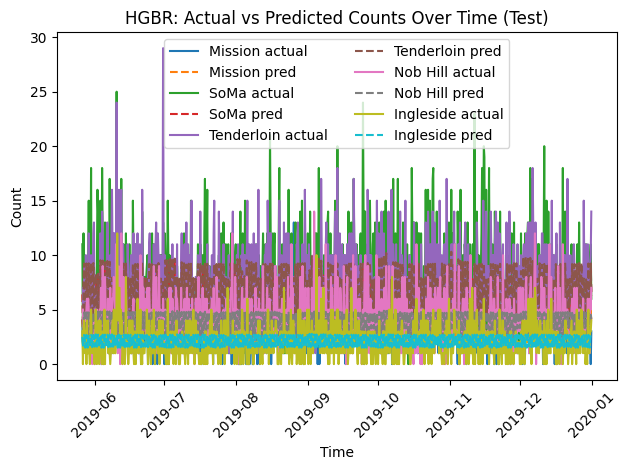

In [190]:
# ----------------------------
# Plots: Predictions vs Actual over time (test)
# Robust alignment using feat_df + X_test.index
# ----------------------------
import matplotlib.pyplot as plt

test_plot_df = feat_df.loc[X_test.index, ["interval_start", "neighborhood", "count"]].copy()
test_plot_df["pred_hgbr"] = pd.Series(np.asarray(y_test_pred_hgbr), index=X_test.index)
test_plot_df = test_plot_df.sort_values(["neighborhood", "interval_start"])

# Plot per neighborhood (time series)
plt.figure()
for nbhd, g in test_plot_df.groupby("neighborhood", observed=True):
    # show actual and predicted as lines (can be busy but acceptable for baseline)
    plt.plot(g["interval_start"], g["count"], label=f"{nbhd} actual")
    plt.plot(g["interval_start"], g["pred_hgbr"], label=f"{nbhd} pred", linestyle="--")
plt.xlabel("Time")
plt.ylabel("Count")
plt.title("HGBR: Actual vs Predicted Counts Over Time (Test)")
plt.xticks(rotation=45)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


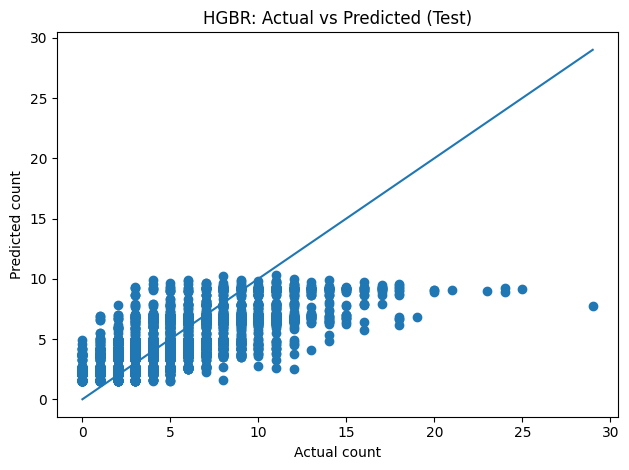

In [191]:
# ----------------------------
# Plots: Combined scatter y_true vs y_pred (test)
# ----------------------------
plt.figure()
plt.scatter(test_plot_df["count"], test_plot_df["pred_hgbr"])
m = min(test_plot_df["count"].min(), test_plot_df["pred_hgbr"].min())
M = max(test_plot_df["count"].max(), test_plot_df["pred_hgbr"].max())
plt.plot([m, M], [m, M])
plt.xlabel("Actual count")
plt.ylabel("Predicted count")
plt.title("HGBR: Actual vs Predicted (Test)")
plt.tight_layout()
plt.show()


In [192]:
# ----------------------------
# Permutation importance (on test set)
# NOTE: requires feature names; we can get them from the preprocessor.
# ----------------------------
# Get transformed feature names
feature_names = best_hgbr_pipe.named_steps["preprocess"].get_feature_names_out()

# These are the columns permutation_importance is permuting
input_feature_names = list(X_test.columns)

# Compute permutation importance on test set
perm = permutation_importance(
    best_hgbr_pipe,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="neg_root_mean_squared_error",
)

importances = pd.DataFrame(
    {
        "feature": input_feature_names,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }
).sort_values("importance_mean", ascending=False)

importances.head(15)


,feature,importance_mean,importance_std
0,neighborhood,1.285093,0.024109
7,hour_cos,0.658246,0.015816
4,dow_sin,0.052321,0.004946
6,hour_sin,0.010668,0.001889
5,dow_cos,0.004229,0.001601
2,month,0.000645,0.000496
1,year,0.000000,0.000000
3,day,-0.000036,0.002011


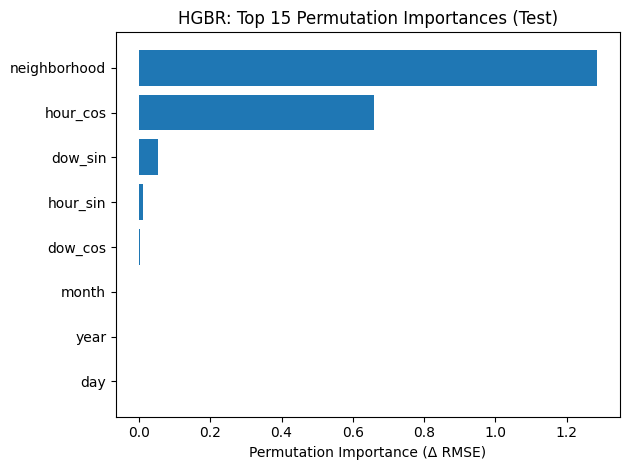

In [193]:
# Quick bar plot of top-k importances (optional)
top_k = 15
top = importances.head(top_k)

plt.figure()
plt.barh(top["feature"][::-1], top["importance_mean"][::-1])
plt.xlabel("Permutation Importance (Δ RMSE)")
plt.title(f"HGBR: Top {top_k} Permutation Importances (Test)")
plt.tight_layout()
plt.show()


* TimeSeriesSplit assumes rows are already time-ordered. If you created `X_train` from a sorted `feat_df`, you are fine.
* The MAE CV summary is computed by manual fold loop (simple + correct).
* Permutation importance can be slow; start with `n_repeats=5` if needed.

In [194]:
len(feature_names)

12

# Poisson Regressor

The mean of **4.6** and median of **4** indicates we can count processes with many low values.

Poisson regression often:
* Improves calibration for low counts (0–3)
* Handles zeros better
* Gives more realistic predictions than Ridge
* Does NOT necessarily fix extreme spikes (that’s nonlinear territory)

## Build Poisson Pipeline

In [195]:
from sklearn.linear_model import PoissonRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


preprocess_poisson = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", drop=None, sparse_output=False), BASE_CATEGORICAL),
        ("num", StandardScaler(), BASE_NUMERIC),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

poisson = PoissonRegressor(
    alpha=1.0,        # regularization (like Ridge)
    max_iter=1000,
)

poisson_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess_poisson),
        ("model", poisson),
    ]
)


In [196]:
# Fit and predict
poisson_pipe.fit(X_train, y_train)

y_train_pred_pois = poisson_pipe.predict(X_train)
y_test_pred_pois  = poisson_pipe.predict(X_test)

In [197]:
y_test_pred_pois.min()  # Should be >=0

np.float64(2.3906252130620187)

## Evaluate with metrics helpers

In [198]:
poisson_train_metrics = regression_metrics(y_train, y_train_pred_pois)
poisson_test_metrics  = regression_metrics(y_test, y_test_pred_pois)

poisson_train_metrics, poisson_test_metrics

({'RMSE': array([6.2502402]),
  'MAE': 1.9407243436286024,
  'MaxError': 16.878520366463466},
 {'RMSE': array([8.15638645]),
  'MAE': 2.126113388046813,
  'MaxError': 21.75378751935216})

In [199]:
rows.append({
    "Model": "PoissonRegressor",
    "Train RMSE": poisson_train_metrics["RMSE"],
    "Test RMSE": poisson_test_metrics["RMSE"],
    "Train MAE": poisson_train_metrics["MAE"],
    "Test MAE": poisson_test_metrics["MAE"],
    "Train MaxError": poisson_train_metrics["MaxError"],
    "Test MaxError": poisson_test_metrics["MaxError"],
})

results_all = pd.DataFrame(rows).set_index("Model")
results_all


,Train RMSE,Test RMSE,Train MAE,Test MAE,Train MaxError,Test MaxError
Model,,,,,,
DummyRegressor (mean),[10.062948644755545],[13.057154069017656],2.517601,2.767791,19.437251,24.437251
Ridge,[5.454649114661952],[6.596588700064784],1.801709,1.888943,15.816258,20.721761
HistGradientBoostingRegressor,4.982263,6.222854,1.724208,1.836943,16.239355,21.230866
PoissonRegressor,[6.250240201035183],[8.156386450494445],1.940724,2.126113,16.878520,21.753788


Poisson regression works best when:

* Counts are generated by a single underlying rate
* Variance is roughly proportional to the mean
* Effects are multiplicative but linear in log-space
* Interactions are weak or unnecessary

In plain English:

> “There is a smooth baseline rate, nudged up or down by features.”

This is a mismatch with our current data:

* Median = 4
* 75% ≤ 6
* Max = 29
* Rare, sharp spikes
* Strong neighborhood effects
* Time-of-day × neighborhood interactions
* Tenderloin behaves qualitatively differently

This is not a single smooth rate process.

It’s closer to:

> “Most of the time things are calm, but occasionally conditions align and everything jumps.”

That violates Poisson’s core assumption.

Ridge regression:

* Minimizes squared error directly
* Can “cheat” by predicting fractional values
* Handles variance flexibly
* Optimized for RMSE/MAE (your metrics)

Poisson regression:

* Optimizes log-likelihood, not RMSE
* Cares more about relative error at low counts
* Is conservative around spikes
* Penalizes overestimation differently than underestimation

# Test Package Installation

## Imports

In [200]:
from importlib import reload
import city_events_ml
reload(city_events_ml)

from city_events_ml.io import TargetSpec, build_target_table
from city_events_ml.features import add_time_features
from city_events_ml.pipelines import FeatureSpec, make_ridge_pipeline, make_hgbr_pipeline, make_poisson_pipeline
from city_events_ml.evaluation import MetricsStore, evaluate_model

## Load Dataset

In [201]:
# Manually set dir if things go awry
os.chdir('C:\\Users\\lover\\Documents\\GitHub\\predicting-safety-events-US-cities-base')

DATA_PATH = None

# Get current path
cwd = PurePath(Path.cwd())

# Use conditional to ensure we do not traverse to higher level dir.
if not DATA_PATH:
    # Change current working directory from `notebooks` directory to one level above.
    os.chdir('..')    
    
    # Construct path to archive location
    DATA_PATH = cwd / 'data'

# Confirm location where data files are stored.
logging.info(str(DATA_PATH))

2026-01-26 10:29:25,652 [INFO] C:\Users\lover\Documents\GitHub\predicting-safety-events-US-cities-base\data


In [210]:
# Load parquet file into dataframe
sf_dataframe = pd.read_parquet(DATA_PATH / 'safety-SanFrancisco-2.parquet')
sf_dataframe.head(1)

,requestId,dataSubtype,dateTime,category,subcategory,status,address,latitude,longitude,source,neighborhood
0,1,911_Fire,2018-10-02 11:54:01,Potentially Life-Threatening,Medical Incident,NaN,ELM ST/FRANKLIN ST,37.781286,-122.422187,NaN,Tenderloin


## Build Dense Target Table

In [202]:
NEIGHBORHOODS = ("Mission", "SoMa", "Tenderloin", "Nob Hill", "Ingleside")
SPEC = TargetSpec(
    category="Potentially Life-Threatening",
    neighborhoods=NEIGHBORHOODS,
    freq="6h",
    start="2016-01-01",
    end="2020-01-01",   # end is exclusive
)

dense = build_target_table(sf_dataframe, spec=SPEC)
dense.head(), dense.shape

(  neighborhood      interval_start  count                      category
 0    Ingleside 2016-01-01 00:00:00      3  Potentially Life-Threatening
 1    Ingleside 2016-01-01 06:00:00      0                           NaN
 2    Ingleside 2016-01-01 12:00:00      0                           NaN
 3    Ingleside 2016-01-01 18:00:00      6                           NaN
 4    Ingleside 2016-01-02 00:00:00      2                           NaN,
 (29220, 4))

In [215]:
dense.shape

(29220, 3)

In [203]:
dense['category'].value_counts()

category
Potentially Life-Threatening    2267
Abandoned Vehicle                  0
311 External Request               0
Blocked Street or SideWalk         0
Catch Basin Maintenance            0
                                ... 
Street Defects                     0
Street and Sidewalk Cleaning       0
Streetlights                       0
Temporary Sign Request             0
Tree Maintenance                   0
Name: count, Length: 95, dtype: int64

### Sanity Checks

In [204]:
dense["count"].describe()

count    29220.000000
mean         4.635010
std          3.241484
min          0.000000
25%          2.000000
50%          4.000000
75%          6.000000
max         29.000000
Name: count, dtype: float64

In [42]:
dense["neighborhood"].value_counts()

neighborhood
Ingleside     5844
Mission       5844
Nob Hill      5844
SoMa          5844
Tenderloin    5844
Name: count, dtype: int64

In [132]:
dense["interval_start"].min(), dense["interval_start"].max()

(Timestamp('2016-01-01 00:00:00'), Timestamp('2019-12-31 18:00:00'))

## Feature Engineering

In [205]:
feat_df = add_time_features(dense, time_col="interval_start")
feat_df.head(1)

,neighborhood,interval_start,count,category,year,month,day,dow,hour,dow_sin,dow_cos,hour_sin,hour_cos
0,Ingleside,2016-01-01,3,Potentially Life-Threatening,2016,1,1,4,0,-0.433884,-0.900969,0.0,1.0


In [44]:
feat_df.columns

Index(['neighborhood', 'interval_start', 'count', 'category', 'year', 'month',
       'day', 'dow', 'hour', 'dow_sin', 'dow_cos', 'hour_sin', 'hour_cos'],
      dtype='object')

## Time Ordered Train/Test Split

In [207]:
feat_df = feat_df.sort_values("interval_start").reset_index(drop=True)

split_idx = int(len(feat_df) * 0.85)
train_df = feat_df.iloc[:split_idx].copy()
test_df  = feat_df.iloc[split_idx:].copy()

feature_spec = FeatureSpec()  # defaults: neighborhood + time cyc features
feature_cols = list(feature_spec.categorical) + list(feature_spec.numeric)
target_col = "count"

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

In [208]:
# Time ordering proof (no overlap)
train_df["interval_start"].max(), test_df["interval_start"].min()

(Timestamp('2019-05-26 18:00:00'), Timestamp('2019-05-26 18:00:00'))

## Train and Evaluate Models

In [209]:
store = MetricsStore()

ridge_pipe = make_ridge_pipeline(feature_spec, alpha=1.0)
hgbr_pipe  = make_hgbr_pipeline(feature_spec)   # defaults in package
pois_pipe  = make_poisson_pipeline(feature_spec, alpha=1.0)

evaluate_model("Ridge", ridge_pipe, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, store=store)
evaluate_model("HistGradientBoostingRegressor", hgbr_pipe, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, store=store)
evaluate_model("PoissonRegressor", pois_pipe, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, store=store)

store.to_frame()

RMSE       MAE   MaxError  \
model                         split                                             
HistGradientBoostingRegressor test   [6.098017699695358]  1.811382  20.720183   
                              train  [4.637891989339513]  1.667721  13.783552   
PoissonRegressor              test   [8.148146552101846]  2.125130  21.750806   
                              train  [6.251006072855028]  1.940864  16.877736   
Ridge                         test    [6.59274714827603]  1.888513  20.719096   
                              train  [5.455083236483335]  1.801788  15.815322   

                                           R2  
model                         split            
HistGradientBoostingRegressor test   0.524233  
                              train  0.539188  
PoissonRegressor              test   0.364282  
                              train  0.378912  
Ridge                         test   0.485634  
                              train  0.457993

## Add Dummy Baseline

In [210]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

yhat_tr = dummy.predict(X_train)
yhat_te = dummy.predict(X_test)

from city_events_ml.evaluation import compute_metrics
store.log(model="DummyRegressor(mean)", split="train", metrics=compute_metrics(y_train, yhat_tr))
store.log(model="DummyRegressor(mean)", split="test", metrics=compute_metrics(y_test, yhat_te))

store.to_frame()


RMSE       MAE  \
model                         split                                   
DummyRegressor(mean)          test   [13.047501456216493]  2.766460   
                              train  [10.064604220686489]  2.517876   
HistGradientBoostingRegressor test    [6.098017699695358]  1.811382   
                              train   [4.637891989339513]  1.667721   
PoissonRegressor              test    [8.148146552101846]  2.125130   
                              train   [6.251006072855028]  1.940864   
Ridge                         test     [6.59274714827603]  1.888513   
                              train   [5.455083236483335]  1.801788   

                                      MaxError        R2  
model                         split                       
DummyRegressor(mean)          test   24.436969 -0.017965  
                              train  19.436969  0.000000  
HistGradientBoostingRegressor test   20.720183  0.524233  
                              train  13.783552  0.539188  
PoissonRegressor              test   21.750806  0.364282  
                              train  16.877736  0.378912  
Ridge                         test   20.719096  0.485634  
                              train  15.815322  0.457993

In [211]:
rows.append({
    "Model": "PoissonRegressor",
    "Train RMSE": poisson_train_metrics["RMSE"],
    "Test RMSE": poisson_test_metrics["RMSE"],
    "Train MAE": poisson_train_metrics["MAE"],
    "Test MAE": poisson_test_metrics["MAE"],
    "Train MaxError": poisson_train_metrics["MaxError"],
    "Test MaxError": poisson_test_metrics["MaxError"],
})

results_all = pd.DataFrame(rows).set_index("Model")
results_all


,Train RMSE,Test RMSE,Train MAE,Test MAE,Train MaxError,Test MaxError
Model,,,,,,
DummyRegressor (mean),[10.062948644755545],[13.057154069017656],2.517601,2.767791,19.437251,24.437251
Ridge,[5.454649114661952],[6.596588700064784],1.801709,1.888943,15.816258,20.721761
HistGradientBoostingRegressor,4.982263,6.222854,1.724208,1.836943,16.239355,21.230866
PoissonRegressor,[6.250240201035183],[8.156386450494445],1.940724,2.126113,16.878520,21.753788
PoissonRegressor,[6.250240201035183],[8.156386450494445],1.940724,2.126113,16.878520,21.753788


## Last 30 Intervals Per Neighborhood

In [212]:
# Fit best model (HGBR) and attach predictions to the test dataframe for inspection
hgbr_pipe.fit(X_train, y_train)
test_view = test_df[["interval_start", "neighborhood", "count"]].copy()
test_view["pred_hgbr"] = hgbr_pipe.predict(X_test)

# Last ~30 intervals per neighborhood
last30 = (
    test_view.sort_values(["neighborhood", "interval_start"])
             .groupby("neighborhood", as_index=False)
             .tail(30)
)
last30

,interval_start,neighborhood,count,pred_hgbr
29070,2019-12-24 12:00:00,Ingleside,3,2.828062
29076,2019-12-24 18:00:00,Ingleside,2,2.288701
29084,2019-12-25 00:00:00,Ingleside,2,1.260108
29086,2019-12-25 06:00:00,Ingleside,0,2.228097
29094,2019-12-25 12:00:00,Ingleside,5,2.828062
...,...,...,...,...
29195,2019-12-30 18:00:00,Tenderloin,8,7.210124
29202,2019-12-31 00:00:00,Tenderloin,2,3.635330
29206,2019-12-31 06:00:00,Tenderloin,9,6.510894
29213,2019-12-31 12:00:00,Tenderloin,10,9.470761


# Package Changed for Bulk Categories

In [370]:
import numpy as np
import pandas as pd

from city_events_ml.io import TargetSpec, build_target_table
from city_events_ml.features import add_time_features
from city_events_ml.pipelines import (
    FeatureSpec,
    make_dummy_pipeline,
    make_ridge_pipeline,
    make_hgbr_pipeline,
    make_poisson_pipeline,
)
from city_events_ml.evaluation import (
    MetricsStore,
    evaluate_model,
    get_feature_names,
    linear_feature_importance,
    hgbr_permutation_importance,
    plot_feature_importance,
)
from city_events_ml.serialization import save_model_skops

## Config

In [371]:
NEIGHBORHOODS = ("Mission", "SoMa", "Tenderloin", "Nob Hill", "Ingleside")

# 2016-2019 inclusive window => end exclusive at 2020-01-01
START = "2016-01-01"
END   = "2020-01-01"

FREQ = "6h"
TEST_SIZE = 0.15

# Run one category, or many:
CATEGORIES = ['Street and Sidewalk Cleaning',
              'Potentially Life-Threatening',
              'Graffiti',
              'Encampments',
              'Non Life-threatening'
             ]

feature_spec = FeatureSpec()  # defaults: neighborhood + time features
feature_cols = list(feature_spec.categorical) + list(feature_spec.numeric)

ARTIFACT_DIR = "artifacts"

## Load Dataset

In [372]:
# Manually set dir if things go awry
os.chdir('C:\\Users\\lover\\Documents\\GitHub\\predicting-safety-events-US-cities-base')

DATA_PATH = None
# Use explicit DATA_PATH, otherwise use relative dir to infer location
#DATA_PATH = PurePath('C:\\Users\\lover\\Documents\\GitHub\\Spotify_Listening_History_Analysis\\data')

# Get current path
cwd = PurePath(Path.cwd())

# Use conditional to ensure we do not traverse to higher level dir.
if not DATA_PATH:
    # Change current working directory from `notebooks` directory to one level above.
    os.chdir('..')    
    
    # Construct path to archive location
    DATA_PATH = cwd / 'data'
    
# Construct query output path
# QUERY_OUTPUT_PATH = cwd / 'data'/ 'sql' / 'query_results'

# Confirm location where data files are stored.
logging.info(str(DATA_PATH))

2026-01-26 11:15:27,150 [INFO] C:\Users\lover\Documents\GitHub\predicting-safety-events-US-cities-base\data


In [373]:
# Load parquet file into dataframe
sf_dataframe = pd.read_parquet(DATA_PATH / 'safety-SanFrancisco-2.parquet')
sf_dataframe.head(1)

,requestId,dataSubtype,dateTime,category,subcategory,status,address,latitude,longitude,source,neighborhood
0,1,911_Fire,2018-10-02 11:54:01,Potentially Life-Threatening,Medical Incident,NaN,ELM ST/FRANKLIN ST,37.781286,-122.422187,NaN,Tenderloin


In [374]:
# Build dataset for a category (dense tabel --> features --> time split)

def make_splits_for_category(
    sf_dataframe: pd.DataFrame,
    *,
    category: str,
    neighborhoods: tuple[str, ...],
    start: str,
    end: str,
    freq: str,
    test_size: float,
    feature_cols: list[str],
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:
    """
    Returns:
      feat_df, train_df, test_df, X_train, y_train, X_test, y_test
    """
    spec = TargetSpec(
        category=category,
        neighborhoods=neighborhoods,
        freq=freq,
        start=start,
        end=end,
    )

    dense = build_target_table(sf_dataframe, spec=spec)
    feat_df = add_time_features(dense, time_col="interval_start")
    feat_df = feat_df.sort_values("interval_start").reset_index(drop=True)

    split_idx = int(len(feat_df) * (1 - test_size))
    train_df = feat_df.iloc[:split_idx].copy()
    test_df  = feat_df.iloc[split_idx:].copy()

    X_train = train_df[feature_cols]
    y_train = train_df["count"]
    X_test  = test_df[feature_cols]
    y_test  = test_df["count"]

    # Time ordering proof (train ends before test begins)
    print("Train end:", train_df["interval_start"].max(), "| Test start:", test_df["interval_start"].min())
    return feat_df, train_df, test_df, X_train, y_train, X_test, y_test


## Run Training / Eval Loop

In [375]:
store = MetricsStore()

for cat in CATEGORIES:
    print(f"\n=== CATEGORY: {cat} ===")

    feat_df, train_df, test_df, X_train, y_train, X_test, y_test = make_splits_for_category(
        sf_dataframe,
        category=cat,
        neighborhoods=NEIGHBORHOODS,
        start=START,
        end=END,
        freq=FREQ,
        test_size=TEST_SIZE,
        feature_cols=feature_cols,
    )

    # Models
    dummy = make_dummy_pipeline("mean")
    ridge = make_ridge_pipeline(feature_spec, alpha=1.0)
    hgbr  = make_hgbr_pipeline(feature_spec)
    pois  = make_poisson_pipeline(feature_spec, alpha=1.0)

    # Evaluate & log (category tracked in store)
    evaluate_model("DummyRegressor(mean)", dummy, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, store=store, category=cat)
    evaluate_model("Ridge", ridge, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, store=store, category=cat)
    evaluate_model("HistGradientBoostingRegressor", hgbr, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, store=store, category=cat)
    evaluate_model("PoissonRegressor", pois, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, store=store, category=cat)

results_df = store.to_frame()
results_df


=== CATEGORY: Street and Sidewalk Cleaning ===
Train end: 2019-05-26 18:00:00 | Test start: 2019-05-26 18:00:00

=== CATEGORY: Potentially Life-Threatening ===
Train end: 2019-05-26 18:00:00 | Test start: 2019-05-26 18:00:00

=== CATEGORY: Graffiti ===
Train end: 2019-05-26 18:00:00 | Test start: 2019-05-26 18:00:00

=== CATEGORY: Encampments ===
Train end: 2019-05-26 18:00:00 | Test start: 2019-05-26 18:00:00

=== CATEGORY: Non Life-threatening ===
Train end: 2019-05-26 18:00:00 | Test start: 2019-05-26 18:00:00


RMSE        MAE  \
model                         split                                    
DummyRegressor(mean)          test   [315.66105918346204]  12.717419   
                              test   [13.047501456216493]   2.766460   
                              test    [34.91849546106956]   4.222823   
                              test    [71.66740308735355]   5.854601   
                              test    [7.060386498486054]   2.092700   
                              train   [160.6292710592482]  10.008496   
                              train  [10.064604220686489]   2.517876   
                              train    [77.9941433859194]   4.970890   
                              train  [31.883563047115835]   4.115343   
                              train  [6.4704315329571225]   2.021285   
HistGradientBoostingRegressor test     [72.9547634904225]   5.243793   
                              test    [6.118826126862472]   1.820082   
                              test    [21.18147904451155]   2.586910   
                              test    [21.98626725682937]   2.786062   
                              test    [3.860945958370009]   1.498334   
                              train  [29.694825862510758]   3.637566   
                              train   [4.611428045441541]   1.663996   
                              train   [45.21056508918386]   3.277431   
                              train   [6.673996527359829]   1.585484   
                              train   [3.649078948151409]   1.469814   
PoissonRegressor              test   [105.96199219554876]   6.590339   
                              test    [8.148146552101856]   2.125130   
                              test   [23.529857898786588]   2.938165   
                              test    [35.29318441646332]   4.223742   
                              test    [4.889341571153399]   1.736699   
                              train   [53.30667542927903]   5.031623   
                              train   [6.251006072855021]   1.940864   
                              train   [59.81404015222663]   3.876018   
                              train  [17.587151117593155]   2.822842   
                              train   [4.660562647005598]   1.682472   
Ridge                         test   [127.56420539882625]   7.359112   
                              test    [6.592747148276026]   1.888513   
                              test    [24.79749570654305]   3.339746   
                              test    [36.45717337884836]   4.206031   
                              test    [4.148265314225649]   1.569363   
                              train   [61.28786872939277]   5.676269   
                              train   [5.455083236483335]   1.801788   
                              train   [60.07656534552887]   4.089788   
                              train   [16.37685178483045]   2.855767   
                              train    [4.06471354081716]   1.552679   

                                       MaxError        R2  \
model                         split                         
DummyRegressor(mean)          test   114.320973 -0.066264   
                              test    24.436969 -0.017965   
                              test    57.569715 -0.044413   
                              test    71.075331 -0.142300   
                              test    20.473729 -0.004974   
                              train   93.320973  0.000000   
                              train   19.436969  0.000000   
                              train  241.569715  0.000000   
                              train   48.075331  0.000000   
                              train   26.473729  0.000000   
HistGradientBoostingRegressor test    64.307975  0.753568   
                              test    20.958863  0.522609   
                              test    51.587625  0.366462   
                              test    51.799297  0.649563   
                              test    16.588585  0.4

## Report Card

In [376]:
results_df.head(1)

,,RMSE,MAE,MaxError,R2,category
model,split,,,,,
DummyRegressor(mean),test,[315.66105918346204],12.717419,114.320973,-0.066264,Street and Sidewalk Cleaning


In [377]:
results_df.index

MultiIndex([(         'DummyRegressor(mean)',  'test'),
            (         'DummyRegressor(mean)',  'test'),
            (         'DummyRegressor(mean)',  'test'),
            (         'DummyRegressor(mean)',  'test'),
            (         'DummyRegressor(mean)',  'test'),
            (         'DummyRegressor(mean)', 'train'),
            (         'DummyRegressor(mean)', 'train'),
            (         'DummyRegressor(mean)', 'train'),
            (         'DummyRegressor(mean)', 'train'),
            (         'DummyRegressor(mean)', 'train'),
            ('HistGradientBoostingRegressor',  'test'),
            ('HistGradientBoostingRegressor',  'test'),
            ('HistGradientBoostingRegressor',  'test'),
            ('HistGradientBoostingRegressor',  'test'),
            ('HistGradientBoostingRegressor',  'test'),
            ('HistGradientBoostingRegressor', 'train'),
            ('HistGradientBoostingRegressor', 'train'),
            ('HistGradientBoostingRegressor', 't

In [378]:
results_df.index.unique()

MultiIndex([(         'DummyRegressor(mean)',  'test'),
            (         'DummyRegressor(mean)', 'train'),
            ('HistGradientBoostingRegressor',  'test'),
            ('HistGradientBoostingRegressor', 'train'),
            (             'PoissonRegressor',  'test'),
            (             'PoissonRegressor', 'train'),
            (                        'Ridge',  'test'),
            (                        'Ridge', 'train')],
           names=['model', 'split'])

In [379]:
# df = results_df.reset_index()

# report = df.pivot_table(
#     index=["category", "model"],
#     columns="split",
#     values=["RMSE", "MAE", "MaxError", "R2"],
#     aggfunc="first",
# )

# report

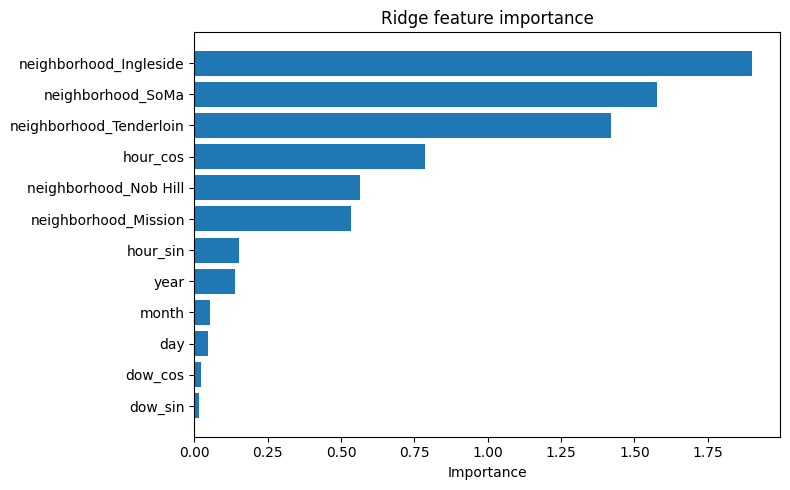

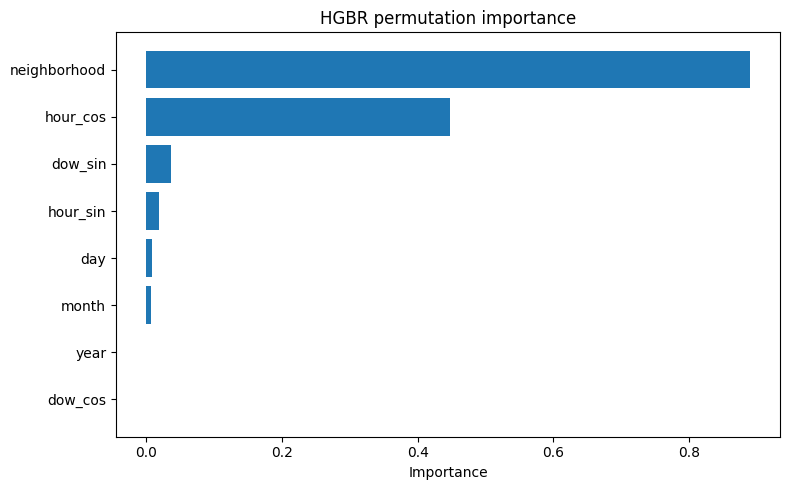

In [380]:
# Ridge
ridge_imp = linear_feature_importance(ridge)
plot_feature_importance(ridge_imp, "importance", "Ridge feature importance")

# HGBR
hgbr_imp = hgbr_permutation_importance(hgbr, X_test, y_test)
plot_feature_importance(hgbr_imp, "importance_mean", "HGBR permutation importance")


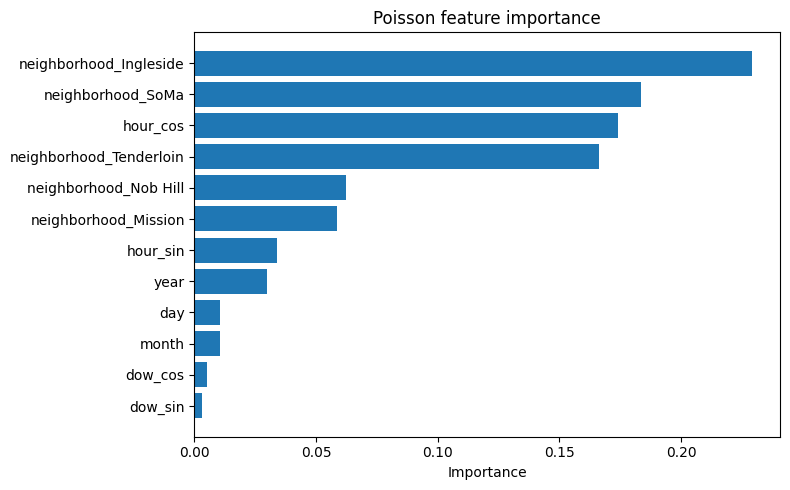

In [381]:
# Ridge
pois_imp = linear_feature_importance(pois)
plot_feature_importance(pois_imp, "importance", "Poisson feature importance")

# Use Weather Data

In [228]:
# Load parquet file into dataframe
# Check https://github.com/awslabs/open-data-docs/tree/main/docs/noaa/noaa-ghcn
# for data spec
sf_weather_df = pd.read_parquet(DATA_PATH / 'weather-data-SF-Nyc-Seattle-2015-2020.parquet')
sf_weather_df.head(5)

,station,date,field,value
0,USW00024233,20150101,TMAX,56
1,USW00024233,20150101,TMIN,-32
2,USW00024233,20150101,PRCP,0
3,USW00024233,20150101,SNWD,0
4,USW00024233,20150101,AWND,12


In [229]:
sf_weather_df['station'].unique()

array(['USW00024233', 'USW00014732', 'USW00023234'], dtype=object)

Check the following TXT document and search for the station.
* http://noaa-ghcn-pds.s3.amazonaws.com/ghcnd-stations.txt

We discovered SF International Airport is `USW00023234`.

In [111]:
len(sf_weather_df)

40393

In [230]:
sf_weather_df = sf_weather_df[sf_weather_df['station'] == 'USW00023234']

In [231]:
sf_weather_df['station'].unique()

array(['USW00023234'], dtype=object)

In [232]:
len(sf_weather_df)

12641

In [233]:
sf_weather_df['field'].unique()

array(['TMAX', 'TMIN', 'PRCP', 'AWND', 'TAVG', 'WSF2', 'SNWD'],
      dtype=object)

* PRCP = Precipitation (tenths of mm)
* SNOW = Snowfall (mm)
* SNWD = Snow depth (mm)
* TMAX = Maximum temperature (tenths of degrees C)
* TMIN = Minimum temperature (tenths of degrees C)
* AWND = Average daily wind speed (tenths of meters per second)
* TAVG = Average temperature (tenths of degrees C) [Note that TAVG from source ’S’ corresponds to an average for the period ending at 2400 UTC rather than local midnight]
* WSF2 = Fastest 2-minute wind speed (tenths of meters per second)

In [234]:
sf_weather_df.describe()

,date,value
count,1.264100e+04,12641.000000
mean,2.017383e+07,95.478997
std,1.571006e+04,72.187428
min,2.015010e+07,0.000000
25%,2.016061e+07,32.000000
50%,2.017112e+07,100.000000
75%,2.019022e+07,144.000000
max,2.020060e+07,792.000000


## Pivot Weather Data From Long to Wide

We need to "pivot" this data apparently.

In [235]:
sf_weather_df.columns

Index(['station', 'date', 'field', 'value'], dtype='object')

In [118]:
sf_weather_df.head(2)

,station,date,field,value
14,USW00023234,20150101,TMAX,128
15,USW00023234,20150101,TMIN,44


In [236]:
# Remove the station, as redundant column value
sf_station_df = sf_weather_df.drop('station', axis=1)

# Render the date column
sf_station_df['date'] = pd.to_datetime(sf_station_df['date'], format="%Y%m%d")

# Create pivot table, date as index, field as columns, values as value
sf_station_pivot = sf_station_df.pivot_table(
                        index='date'
                        ,columns="field"
                        ,values="value"
                        ,aggfunc="mean" # In case we have dupe entries
                        ).sort_index()
sf_station_pivot.columns.name = None
sf_station_pivot.head(10)

,AWND,PRCP,SNWD,TAVG,TMAX,TMIN,WSF2
date,,,,,,,
2015-01-01,38.0,0.0,NaN,97.0,128.0,44.0,89.0
2015-01-02,7.0,0.0,NaN,77.0,111.0,33.0,31.0
2015-01-03,7.0,0.0,NaN,77.0,122.0,33.0,31.0
2015-01-04,9.0,0.0,NaN,86.0,128.0,50.0,63.0
2015-01-05,11.0,0.0,NaN,98.0,150.0,61.0,31.0
2015-01-06,9.0,0.0,NaN,108.0,156.0,67.0,36.0
2015-01-07,9.0,0.0,NaN,116.0,156.0,72.0,31.0
2015-01-08,4.0,0.0,NaN,120.0,156.0,94.0,31.0
2015-01-09,16.0,0.0,NaN,125.0,172.0,106.0,58.0


In [237]:
sf_station_pivot.describe()

,AWND,PRCP,SNWD,TAVG,TMAX,TMIN,WSF2
count,1980.000000,1981.000000,796.0,1982.000000,1961.000000,1961.000000,1980.000000
mean,45.742424,12.622918,0.0,146.913724,194.501275,110.468129,102.093939
std,20.304536,48.908301,0.0,31.087168,45.072664,30.073908,30.926885
min,4.000000,0.000000,0.0,54.000000,89.000000,11.000000,22.000000
25%,31.000000,0.000000,0.0,126.000000,161.000000,94.000000,81.000000
50%,45.000000,0.000000,0.0,147.000000,194.000000,111.000000,103.000000
75%,59.000000,0.000000,0.0,167.000000,222.000000,128.000000,116.000000
max,113.000000,792.000000,0.0,282.000000,400.000000,222.000000,233.000000


In [121]:
sf_station_pivot.head(1)

,AWND,PRCP,SNWD,TAVG,TMAX,TMIN,WSF2
date,,,,,,,
2015-01-01,38.0,0.0,NaN,97.0,128.0,44.0,89.0


In [122]:
%store -r feat_df

In [238]:
feat_df.columns

Index(['neighborhood', 'interval_start', 'count', 'category', 'year', 'month',
       'day', 'dow', 'hour', 'dow_sin', 'dow_cos', 'hour_sin', 'hour_cos'],
      dtype='object')

In [239]:
feat_df['category'].value_counts()

category
Non Life-threatening            1095
Abandoned Vehicle                  0
311 External Request               0
Blocked Street or SideWalk         0
Catch Basin Maintenance            0
                                ... 
Street Defects                     0
Street and Sidewalk Cleaning       0
Streetlights                       0
Temporary Sign Request             0
Tree Maintenance                   0
Name: count, Length: 95, dtype: int64

## Merge Weather Data with Current Data

In [ ]:
# Confirm our columns
sf_station_pivot.loc[foo['interval_start']]

In [ ]:
# Test Dataframe
foo = feat_df.head(5)

foo = foo.merge(sf_station_pivot, left_on='interval_start', right_on='date')
foo

In [242]:
# Create a copy of feat_df
feat_df_date = feat_df.copy()

# Set a column *just* with a date. This is an 'object' datatype
feat_df_date['date'] = feat_df_date['interval_start'].dt.date

# Turn the object back into a datetime
feat_df_date['date'] = pd.to_datetime(feat_df_date['date'])

# Merge the dataframes on date coumns
feat_df_date = feat_df_date.merge(sf_station_pivot, left_on='date', right_on='date')

# We cannot join `interval_start` directly with `date` since it will only match with 00:00:00 and not subsequent hours.
feat_df_date.head(10)

,neighborhood,interval_start,count,category,year,month,day,dow,hour,dow_sin,...,hour_sin,hour_cos,date,AWND,PRCP,SNWD,TAVG,TMAX,TMIN,WSF2
0,Ingleside,2016-01-01 00:00:00,2,NaN,2016,1,1,4,0,-0.433884,...,0.0,1.000000e+00,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0
1,Tenderloin,2016-01-01 00:00:00,15,NaN,2016,1,1,4,0,-0.433884,...,0.0,1.000000e+00,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0
2,SoMa,2016-01-01 00:00:00,11,NaN,2016,1,1,4,0,-0.433884,...,0.0,1.000000e+00,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0
3,Nob Hill,2016-01-01 00:00:00,7,NaN,2016,1,1,4,0,-0.433884,...,0.0,1.000000e+00,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0
4,Mission,2016-01-01 00:00:00,3,NaN,2016,1,1,4,0,-0.433884,...,0.0,1.000000e+00,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0
5,SoMa,2016-01-01 06:00:00,4,NaN,2016,1,1,4,6,-0.433884,...,1.0,6.123234e-17,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0
6,Nob Hill,2016-01-01 06:00:00,5,NaN,2016,1,1,4,6,-0.433884,...,1.0,6.123234e-17,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0
7,Tenderloin,2016-01-01 06:00:00,4,NaN,2016,1,1,4,6,-0.433884,...,1.0,6.123234e-17,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0
8,Ingleside,2016-01-01 06:00:00,1,NaN,2016,1,1,4,6,-0.433884,...,1.0,6.123234e-17,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0
9,Mission,2016-01-01 06:00:00,1,NaN,2016,1,1,4,6,-0.433884,...,1.0,6.123234e-17,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0


In [ ]:
feat_df_date.dtypes

In [ ]:
# Save the merged dataframe
%store feat_df_date

In [ ]:
%store -r feat_df feat_df_date

In [ ]:
feat_df.columns

# Add Holiday Data

In [243]:
import holidays
from datetime import date
import holidays

us_holidays = holidays.US()  # this is a dict-like object
# the below is the same, but takes a string:
us_holidays = holidays.country_holidays('US')  # this is a dict-like object


In [244]:
date(2015, 1, 1) in us_holidays  # True
date(2015, 1, 2) in us_holidays  # False
us_holidays.get('2014-01-01')  # "New Year's Day"
holiday_dates = set(us_holidays.keys())

# Create new dataframe with holiday col
feat_df_date_holiday = feat_df_date.copy()
feat_df_date_holiday["is_holiday"] = feat_df_date["interval_start"].dt.date.isin(holiday_dates)
feat_df_date_holiday.head(5)

,neighborhood,interval_start,count,category,year,month,day,dow,hour,dow_sin,...,hour_cos,date,AWND,PRCP,SNWD,TAVG,TMAX,TMIN,WSF2,is_holiday
0,Ingleside,2016-01-01,2,NaN,2016,1,1,4,0,-0.433884,...,1.0,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,False
1,Tenderloin,2016-01-01,15,NaN,2016,1,1,4,0,-0.433884,...,1.0,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,False
2,SoMa,2016-01-01,11,NaN,2016,1,1,4,0,-0.433884,...,1.0,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,False
3,Nob Hill,2016-01-01,7,NaN,2016,1,1,4,0,-0.433884,...,1.0,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,False
4,Mission,2016-01-01,3,NaN,2016,1,1,4,0,-0.433884,...,1.0,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,False


In [245]:
us_holidays.get('2016-01-02')

In [246]:
import holidays

us_holidays = holidays.US()

holiday_dates = set(us_holidays.keys())  # <-- THIS is the fix

#df["is_holiday"] = df["interval_start"].dt.date.isin(holiday_dates)
holiday_dates

set()

In [63]:
# feat_df['is_holiday'] = 
# print(int(isinstance(us_holidays.get(date_string), str)))

In [262]:
import holidays

# interval_start is datetime64[ns]
years = feat_df["interval_start"].dt.year.unique().tolist()

us_holidays = holidays.US(years=years)   # <-- forces generation for those years
holiday_dates = set(us_holidays)         # iterating yields the holiday dates

feat_df_date_holiday = feat_df_date.copy()
feat_df_date_holiday["is_holiday"] = feat_df_date["interval_start"].dt.date.isin(holiday_dates)
feat_df_date_holiday.head(50)

,neighborhood,interval_start,count,category,year,month,day,dow,hour,dow_sin,...,hour_cos,date,AWND,PRCP,SNWD,TAVG,TMAX,TMIN,WSF2,is_holiday
0,Ingleside,2016-01-01 00:00:00,2,NaN,2016,1,1,4,0,-0.433884,...,1.000000e+00,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,True
1,Tenderloin,2016-01-01 00:00:00,15,NaN,2016,1,1,4,0,-0.433884,...,1.000000e+00,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,True
2,SoMa,2016-01-01 00:00:00,11,NaN,2016,1,1,4,0,-0.433884,...,1.000000e+00,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,True
3,Nob Hill,2016-01-01 00:00:00,7,NaN,2016,1,1,4,0,-0.433884,...,1.000000e+00,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,True
4,Mission,2016-01-01 00:00:00,3,NaN,2016,1,1,4,0,-0.433884,...,1.000000e+00,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,True
5,SoMa,2016-01-01 06:00:00,4,NaN,2016,1,1,4,6,-0.433884,...,6.123234e-17,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,True
6,Nob Hill,2016-01-01 06:00:00,5,NaN,2016,1,1,4,6,-0.433884,...,6.123234e-17,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,True
7,Tenderloin,2016-01-01 06:00:00,4,NaN,2016,1,1,4,6,-0.433884,...,6.123234e-17,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,True
8,Ingleside,2016-01-01 06:00:00,1,NaN,2016,1,1,4,6,-0.433884,...,6.123234e-17,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,True
9,Mission,2016-01-01 06:00:00,1,NaN,2016,1,1,4,6,-0.433884,...,6.123234e-17,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,True


In [263]:
# Sanity check
len(holiday_dates), sorted(list(holiday_dates))[:5]
feat_df_date_holiday["is_holiday"].value_counts(dropna=False)

is_holiday
False    28340
True       880
Name: count, dtype: int64

In [264]:
# Add in California Hholidays
ca_holidays = holidays.US(state="CA", years=years)
holiday_dates = set(ca_holidays)

feat_df_date_holiday["is_ca_holiday"] = feat_df_date_holiday["interval_start"].dt.date.isin(holiday_dates)

In [265]:
# Sanity check after we add CA holidays
len(holiday_dates), sorted(list(holiday_dates))[:5]
feat_df_date_holiday["is_ca_holiday"].value_counts(dropna=False)

is_ca_holiday
False    28180
True      1040
Name: count, dtype: int64

In [266]:
def add_holidays_to_df(feat_df):
    feat_df = feat_df.copy()
    # interval_start is datetime64[ns]
    years = feat_df["interval_start"].dt.year.unique().tolist()
    
    us_holidays = holidays.US(years=years)   # <-- forces generation for those years
    holiday_dates = set(us_holidays)         # iterating yields the holiday dates
    
    feat_df["is_holiday"] = feat_df["interval_start"].dt.date.isin(holiday_dates)
    
    # Add in California Hholidays
    ca_holidays = holidays.US(state="CA", years=years)
    holiday_dates = set(ca_holidays)
    
    feat_df["is_ca_holiday"] = feat_df["interval_start"].dt.date.isin(holiday_dates)
    return feat_df


In [267]:
%store feat_df_date_holiday

Stored 'feat_df_date_holiday' (DataFrame)


In [91]:
%store -r feat_df_date_holiday

In [268]:
feat_df_date_holiday.head(1)

,neighborhood,interval_start,count,category,year,month,day,dow,hour,dow_sin,...,date,AWND,PRCP,SNWD,TAVG,TMAX,TMIN,WSF2,is_holiday,is_ca_holiday
0,Ingleside,2016-01-01,2,NaN,2016,1,1,4,0,-0.433884,...,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,True,True


Now we have a conundrum. We can add street cleaning schedule data, but that data has "cnn" and not a neighborhood.
* Map a neighborhood to CNN
* Aggregate or process the schedule so that we get numerical data per neighborhood.
* Assign / associate the count street cleanings to `dow`. 

## Read SF Open Data CSVs

In [269]:
import pathlib
# set root path
ROOT = pathlib.Path().resolve().parents[0]

# Create path object for wyscout
sf_data_path = ROOT / "Github"/ "predicting_urban_events_with_scikit_learn"/ "data"  


In [270]:
sf_data_path

WindowsPath('C:/Users/lover/Documents/Github/predicting_urban_events_with_scikit_learn/data')

In [271]:
streets_path = sf_data_path / "Streets_–_Active_and_Retired_20260118.csv"

In [272]:
streets_df = pd.read_csv(streets_path)
streets_df.head(1)

,cnn,lf_fadd,lf_toadd,rt_fadd,rt_toadd,street,st_type,f_st,t_st,f_node_cnn,...,oneway,street_gc,streetname,streetname_gc,zip_code,analysis_neighborhood,supervisor_district,line,data_as_of,data_loaded_at
0,944000,1101.0,1199.0,1100.0,1198.0,19TH,ST,PENNSYLVANIA AVE,MISSISSIPPI ST,23649000.0,...,B,19TH,19TH ST,19TH ST,94107.0,Potrero Hill,10.0,"LINESTRING (-122.393488387 37.761476161, -122....",2026/01/17 03:57:00 AM,2026/01/17 10:14:19 AM


In [83]:
print(streets_df.head(1)['line'])

0    LINESTRING (-122.393488387 37.761476161, -122....
Name: line, dtype: object


In [273]:
sweeping_schedule_path = sf_data_path / "Street_Sweeping_Schedule_20260118.csv"

In [274]:
sweeping_schedule_df = pd.read_csv(sweeping_schedule_path)
sweeping_schedule_df.head(1)

,CNN,Corridor,Limits,CNNRightLeft,BlockSide,FullName,WeekDay,FromHour,ToHour,Week1,Week2,Week3,Week4,Week5,Holidays,BlockSweepID,Line
0,8753101,Market St,Larkin St - Polk St,L,SouthEast,Tuesday,Tues,5,6,1,1,1,1,1,0,1640782,"LINESTRING (-122.416291701103 37.777493843394,..."


In [78]:
import duckdb

In [86]:
duckdb.sql("""
SELECT 
    -- schedule.cnn
    DISTINCT (streets.analysis_neighborhood
    ,schedule.weekday) AS neighborhood_and_day
    ,COUNT(analysis_neighborhood) AS hood_count
FROM streets_df AS streets
JOIN sweeping_schedule_df AS schedule
    ON schedule.CNN = streets.cnn
--WHERE streets.active = True
GROUP BY 
    streets.analysis_neighborhood
    ,schedule.cnn
    ,schedule.weekday
HAVING hood_count > 0
ORDER BY 
    hood_count DESC
    ,neighborhood_and_day ASC

""")

┌─────────────────────────────┬────────────┐
│    neighborhood_and_day     │ hood_count │
│  struct(varchar, varchar)   │   int64    │
├─────────────────────────────┼────────────┤
│ (Bernal Heights, Fri)       │          4 │
│ (Bernal Heights, Mon)       │          4 │
│ (Bernal Heights, Thu)       │          4 │
│ (Bernal Heights, Tues)      │          4 │
│ (Bernal Heights, Wed)       │          4 │
│ (Chinatown, Tues)           │          4 │
│ (Japantown, Fri)            │          4 │
│ (Lakeshore, Tues)           │          4 │
│ (Lakeshore, Wed)            │          4 │
│ (Lone Mountain/USF, Mon)    │          4 │
│            ·                │          · │
│            ·                │          · │
│            ·                │          · │
│ (West of Twin Peaks, Tues)  │          1 │
│ (West of Twin Peaks, Wed)   │          1 │
│ (Western Addition, Fri)     │          1 │
│ (Western Addition, Holiday) │          1 │
│ (Western Addition, Mon)     │          1 │
│ (Western

We can render the SQL output into a dataframe...
* We can then add columns based on the neighborhood and day
* Separately, we then populate our feature dataframe, by looking up from the SQL result by the neighborhood + day of week
* Get the count of cleanings that day of week
* Add the count of cleanings in that neighborhood and dow to thefeature dataframe

We must be cautious that the Day of Week we translate from our SQL maps correctly into the feature dataframe.

In [275]:
feat_df_holidays.head(30).query('dow == 6')

,neighborhood,interval_start,count,year,month,day,dow,hour,dow_sin,dow_cos,...,hour_cos,AWND,PRCP,SNWD,TAVG,TMAX,TMIN,WSF2,is_holiday,is_ca_holiday
10,SoMa,2016-01-03,3,2016,1,3,6,0,-0.781831,0.62349,...,1.0,9.0,10.0,NaN,88.0,117.0,67.0,40.0,False,False
11,Mission,2016-01-03,3,2016,1,3,6,0,-0.781831,0.62349,...,1.0,9.0,10.0,NaN,88.0,117.0,67.0,40.0,False,False
12,Tenderloin,2016-01-03,9,2016,1,3,6,0,-0.781831,0.62349,...,1.0,9.0,10.0,NaN,88.0,117.0,67.0,40.0,False,False
13,Ingleside,2016-01-03,4,2016,1,3,6,0,-0.781831,0.62349,...,1.0,9.0,10.0,NaN,88.0,117.0,67.0,40.0,False,False
14,Nob Hill,2016-01-03,0,2016,1,3,6,0,-0.781831,0.62349,...,1.0,9.0,10.0,NaN,88.0,117.0,67.0,40.0,False,False


So, Day 0, in our feature dataframe is "Monday." Here is our lookup.
* 0 = Monday
* 1 = Tuesday
* 2 = Wednesday
* 3 = Thursday
* 4 = Friday
* 5 = Saturday
* 6 = Sunday

In [261]:
%store feat_df_holidays

In [93]:
feat_df_holidays.columns

Index(['neighborhood', 'interval_start', 'count', 'year', 'month', 'day',
       'dow', 'hour', 'dow_sin', 'dow_cos', 'hour_sin', 'hour_cos', 'AWND',
       'PRCP', 'SNWD', 'TAVG', 'TMAX', 'TMIN', 'WSF2', 'is_holiday',
       'is_ca_holiday'],
      dtype='object')

# Use Street Sweeping Data

In [89]:
duckdb.sql("""
SELECT 
    streets.analysis_neighborhood
    ,schedule.weekday
--    ,COUNT (DISTINCT schedule.cnn)
--    ,COUNT schedule.cnn
    --DISTINCT (streets.analysis_neighborhood
    --,schedule.weekday) AS neighborhood_and_day
FROM sweeping_schedule_df AS schedule

JOIN streets_df AS streets
    ON schedule.CNN = streets.cnn
WHERE 
    streets.analysis_neighborhood IS NOT NULL
    -- AND streets.analysis_neighborhood = 'Twin Peaks'
GROUP BY 
    streets.analysis_neighborhood
    ,schedule.weekday
ORDER BY 
    COUNT(schedule.cnn) DESC
    
""")

┌────────────────────────────────┬─────────┐
│     analysis_neighborhood      │ WeekDay │
│            varchar             │ varchar │
├────────────────────────────────┼─────────┤
│ Sunset/Parkside                │ Tues    │
│ Sunset/Parkside                │ Thu     │
│ Sunset/Parkside                │ Mon     │
│ Sunset/Parkside                │ Fri     │
│ Mission                        │ Thu     │
│ Mission                        │ Tues    │
│ Mission                        │ Fri     │
│ West of Twin Peaks             │ Wed     │
│ Mission                        │ Mon     │
│ Financial District/South Beach │ Mon     │
│      ·                         │  ·      │
│      ·                         │  ·      │
│      ·                         │  ·      │
│ Inner Sunset                   │ Sun     │
│ Hayes Valley                   │ Sun     │
│ Western Addition               │ Holiday │
│ Oceanview/Merced/Ingleside     │ Sat     │
│ Presidio                       │ Mon     │
│ Haight A

In [164]:
duckdb.sql("""
SELECT 
    streets.analysis_neighborhood
    ,schedule.weekday
--    ,COUNT (DISTINCT schedule.cnn)
    ,COUNT (schedule.cnn)
    --DISTINCT (streets.analysis_neighborhood
    --,schedule.weekday) AS neighborhood_and_day
FROM sweeping_schedule_df AS schedule

JOIN streets_df AS streets
    ON schedule.CNN = streets.cnn
WHERE 
    streets.analysis_neighborhood IS NOT NULL
    -- AND streets.analysis_neighborhood = 'Twin Peaks'
GROUP BY 
    streets.analysis_neighborhood
    ,schedule.weekday
ORDER BY 
    COUNT(schedule.cnn) DESC
    
""")

┌────────────────────────────────┬─────────┬─────────────────────┐
│     analysis_neighborhood      │ WeekDay │ count(schedule.cnn) │
│            varchar             │ varchar │        int64        │
├────────────────────────────────┼─────────┼─────────────────────┤
│ Sunset/Parkside                │ Tues    │                 760 │
│ Sunset/Parkside                │ Thu     │                 700 │
│ Sunset/Parkside                │ Mon     │                 678 │
│ Sunset/Parkside                │ Fri     │                 665 │
│ Mission                        │ Thu     │                 626 │
│ Mission                        │ Tues    │                 612 │
│ Mission                        │ Fri     │                 550 │
│ West of Twin Peaks             │ Wed     │                 547 │
│ Mission                        │ Mon     │                 526 │
│ Financial District/South Beach │ Mon     │                 505 │
│        ·                       │  ·      │                  

In [169]:
duckdb.query("""
SELECT
    streets.analysis_neighborhood,
    schedule.weekday,
    COUNT(DISTINCT schedule.cnn) AS scheduled_street_segments
FROM sweeping_schedule_df AS schedule
JOIN streets_df AS streets
  ON schedule.cnn = streets.cnn
WHERE streets.analysis_neighborhood IS NOT NULL
AND streets.active = True
GROUP BY 1, 2
ORDER BY scheduled_street_segments DESC;
""")

┌────────────────────────────┬─────────┬───────────────────────────┐
│   analysis_neighborhood    │ WeekDay │ scheduled_street_segments │
│          varchar           │ varchar │           int64           │
├────────────────────────────┼─────────┼───────────────────────────┤
│ Sunset/Parkside            │ Tues    │                       620 │
│ Sunset/Parkside            │ Thu     │                       579 │
│ Sunset/Parkside            │ Mon     │                       575 │
│ Mission                    │ Tues    │                       552 │
│ Sunset/Parkside            │ Fri     │                       536 │
│ Mission                    │ Thu     │                       535 │
│ Mission                    │ Fri     │                       486 │
│ Mission                    │ Mon     │                       465 │
│ West of Twin Peaks         │ Wed     │                       458 │
│ Bayview Hunters Point      │ Thu     │                       435 │
│        ·                   │  · 

In [170]:
duckdb.query("""SELECT cnn, COUNT(*) AS n
FROM streets_df
GROUP BY 1
HAVING COUNT(*) > 1
ORDER BY n DESC
LIMIT 20;
""")

┌───────┬───────┐
│  cnn  │   n   │
│ int64 │ int64 │
├───────┴───────┤
│    0 rows     │
└───────────────┘

In [172]:
duckdb.query("""SELECT cnn, weekday, COUNT(*) AS n
FROM sweeping_schedule_df
GROUP BY 1, 2
HAVING COUNT(*) > 1
ORDER BY n DESC
LIMIT 20;
""")

┌──────────┬─────────┬───────┐
│   CNN    │ WeekDay │   n   │
│  int64   │ varchar │ int64 │
├──────────┼─────────┼───────┤
│  9130000 │ Wed     │     4 │
│  9144000 │ Thu     │     4 │
│  9145000 │ Fri     │     4 │
│  9133000 │ Thu     │     4 │
│  9140000 │ Wed     │     4 │
│  9134000 │ Thu     │     4 │
│  9145000 │ Thu     │     4 │
│  9138000 │ Tues    │     4 │
│  9138000 │ Mon     │     4 │
│  9139000 │ Thu     │     4 │
│  9130000 │ Fri     │     4 │
│  9138000 │ Fri     │     4 │
│  9129000 │ Wed     │     4 │
│  2566000 │ Fri     │     4 │
│  9130000 │ Mon     │     4 │
│ 12611000 │ Tues    │     4 │
│  9145000 │ Tues    │     4 │
│  9145000 │ Mon     │     4 │
│  9146000 │ Thu     │     4 │
│  8562000 │ Mon     │     4 │
├──────────┴─────────┴───────┤
│ 20 rows          3 columns │
└────────────────────────────┘

In [276]:
streets_df.columns

Index(['cnn', 'lf_fadd', 'lf_toadd', 'rt_fadd', 'rt_toadd', 'street',
       'st_type', 'f_st', 't_st', 'f_node_cnn', 't_node_cnn', 'accepted',
       'active', 'classcode', 'date_added', 'date_altered', 'date_dropped',
       'gds_chg_id_add', 'gds_chg_id_altered', 'gds_chg_id_dropped',
       'jurisdiction', 'layer', 'nhood', 'oneway', 'street_gc', 'streetname',
       'streetname_gc', 'zip_code', 'analysis_neighborhood',
       'supervisor_district', 'line', 'data_as_of', 'data_loaded_at'],
      dtype='object')

In [174]:
duckdb.query("""SELECT *
FROM sweeping_schedule_df
WHERE cnn = 9130000 AND weekday = 'Wed'
LIMIT 50;
""")


┌─────────┬────────────┬────────────────────────────┬──────────────┬───────────┬───────────────────┬─────────┬──────────┬────────┬───────┬───────┬───────┬───────┬───────┬──────────┬──────────────┬───────────────────────────────────────────────────────────────────────────────────┐
│   CNN   │  Corridor  │           Limits           │ CNNRightLeft │ BlockSide │     FullName      │ WeekDay │ FromHour │ ToHour │ Week1 │ Week2 │ Week3 │ Week4 │ Week5 │ Holidays │ BlockSweepID │                                       Line                                        │
│  int64  │  varchar   │          varchar           │   varchar    │  varchar  │      varchar      │ varchar │  int64   │ int64  │ int64 │ int64 │ int64 │ int64 │ int64 │  int64   │    int64     │                                      varchar                                      │
├─────────┼────────────┼────────────────────────────┼──────────────┼───────────┼───────────────────┼─────────┼──────────┼────────┼───────┼───────┼───────┼───

In [175]:
duckdb.query("""WITH date_spine AS (
  SELECT
    d::DATE AS dt,
    strftime(d::DATE, '%a') AS weekday, -- Mon/Tue/Wed...
    1 + ((extract(day from d::DATE) - 1) / 7) AS week_of_month
  FROM generate_series(date '2016-01-01', date '2019-12-31', interval 1 day) AS t(d)
)
SELECT * FROM date_spine LIMIT 10;
""")

┌────────────┬─────────┬────────────────────┐
│     dt     │ weekday │   week_of_month    │
│    date    │ varchar │       double       │
├────────────┼─────────┼────────────────────┤
│ 2016-01-01 │ Fri     │                1.0 │
│ 2016-01-02 │ Sat     │ 1.1428571428571428 │
│ 2016-01-03 │ Sun     │ 1.2857142857142856 │
│ 2016-01-04 │ Mon     │ 1.4285714285714286 │
│ 2016-01-05 │ Tue     │ 1.5714285714285714 │
│ 2016-01-06 │ Wed     │ 1.7142857142857144 │
│ 2016-01-07 │ Thu     │ 1.8571428571428572 │
│ 2016-01-08 │ Fri     │                2.0 │
│ 2016-01-09 │ Sat     │  2.142857142857143 │
│ 2016-01-10 │ Sun     │ 2.2857142857142856 │
├────────────┴─────────┴────────────────────┤
│ 10 rows                         3 columns │
└───────────────────────────────────────────┘

In [253]:
# Join schedule to our "date spine" using weekday + week of the month.
# "How many schedule street-side sweeps exist on that date in that neighborhood?"

duckdb.query("""
WITH date_spine AS (
  SELECT
    d::DATE AS dt,
    strftime(d::DATE, '%a') AS weekday,
    1 + ((extract(day from d::DATE) - 1) / 7) AS week_of_month
  FROM generate_series(date '2016-01-01', date '2019-12-31', interval 1 day) AS t(d)
),
sched AS (
  SELECT
    schedule.cnn,
    schedule.weekday,
    schedule.fromhour,
    schedule.tohour,
    schedule.week1, schedule.week2, schedule.week3, schedule.week4, schedule.week5
  FROM sweeping_schedule_df AS schedule
),
joined AS (
  SELECT
    streets.analysis_neighborhood,
    ds.dt,
    ds.weekday,
    ds.week_of_month,
    sched.cnn
  FROM date_spine ds
  JOIN sched
    ON sched.weekday = ds.weekday
   AND (
        (ds.week_of_month = 1 AND sched.week1 = 1) OR
        (ds.week_of_month = 2 AND sched.week2 = 1) OR
        (ds.week_of_month = 3 AND sched.week3 = 1) OR
        (ds.week_of_month = 4 AND sched.week4 = 1) OR
        (ds.week_of_month = 5 AND sched.week5 = 1)
      )
  JOIN streets_df streets
    ON streets.cnn = sched.cnn
  WHERE streets.analysis_neighborhood IS NOT NULL
    AND streets.active = 'True'
)
SELECT
  analysis_neighborhood,
  dt,
  COUNT(*) AS scheduled_sweeps
FROM joined
GROUP BY 1, 2
ORDER BY scheduled_sweeps DESC;


""")

┌───────────────────────┬────────────┬──────────────────┐
│ analysis_neighborhood │     dt     │ scheduled_sweeps │
│        varchar        │    date    │      int64       │
├───────────────────────┼────────────┼──────────────────┤
│ Mission               │ 2017-06-08 │              578 │
│ Mission               │ 2019-08-22 │              578 │
│ Mission               │ 2018-11-22 │              578 │
│ Mission               │ 2018-03-08 │              578 │
│ Mission               │ 2016-09-22 │              578 │
│ Mission               │ 2016-12-08 │              578 │
│ Mission               │ 2019-08-08 │              578 │
│ Mission               │ 2018-02-08 │              578 │
│ Mission               │ 2017-06-22 │              578 │
│ Mission               │ 2016-09-08 │              578 │
│    ·                  │     ·      │                · │
│    ·                  │     ·      │                · │
│    ·                  │     ·      │                · │
│ Twin Peaks  

In [255]:
# Join schedule to our "date spine" using weekday + week of the month.
# "How many schedule street-side sweeps exist on that date in that neighborhood?"

duckdb.query("""
WITH date_spine AS (
  SELECT
    d::DATE AS dt,
    strftime(d::DATE, '%a') AS weekday,
    1 + ((extract(day from d::DATE) - 1) / 7) AS week_of_month
  FROM generate_series(date '2016-01-01', date '2019-12-31', interval 1 day) AS t(d)
),
sched AS (
  SELECT
    schedule.cnn,
    schedule.weekday,
    schedule.fromhour,
    schedule.tohour,
    schedule.week1, schedule.week2, schedule.week3, schedule.week4, schedule.week5
  FROM sweeping_schedule_df AS schedule
),
joined AS (
  SELECT
    streets.analysis_neighborhood,
    ds.dt,
    ds.weekday,
    ds.week_of_month,
    sched.cnn,
    sched.fromhour,
    sched.tohour
  FROM date_spine ds
  JOIN sched
    ON sched.weekday = ds.weekday
   AND (
        (ds.week_of_month = 1 AND sched.week1 = 1) OR
        (ds.week_of_month = 2 AND sched.week2 = 1) OR
        (ds.week_of_month = 3 AND sched.week3 = 1) OR
        (ds.week_of_month = 4 AND sched.week4 = 1) OR
        (ds.week_of_month = 5 AND sched.week5 = 1)
      )
  JOIN streets_df streets
    ON streets.cnn = sched.cnn
  WHERE streets.analysis_neighborhood IS NOT NULL
    AND streets.active = 'True'
)
SELECT
  analysis_neighborhood,
  dt,
  fromhour,
  tohour,
  COUNT(*) AS scheduled_sweeps
FROM joined
GROUP BY 1, 2, 3, 4
ORDER BY scheduled_sweeps DESC;


""")

┌────────────────────────────────┬────────────┬──────────┬────────┬──────────────────┐
│     analysis_neighborhood      │     dt     │ FromHour │ ToHour │ scheduled_sweeps │
│            varchar             │    date    │  int64   │ int64  │      int64       │
├────────────────────────────────┼────────────┼──────────┼────────┼──────────────────┤
│ Financial District/South Beach │ 2017-05-15 │        2 │      6 │              288 │
│ Financial District/South Beach │ 2016-02-22 │        2 │      6 │              288 │
│ Financial District/South Beach │ 2018-01-15 │        2 │      6 │              288 │
│ Financial District/South Beach │ 2016-02-29 │        2 │      6 │              288 │
│ Financial District/South Beach │ 2016-08-15 │        2 │      6 │              288 │
│ Financial District/South Beach │ 2017-05-01 │        2 │      6 │              288 │
│ Financial District/South Beach │ 2018-01-08 │        2 │      6 │              288 │
│ Financial District/South Beach │ 2016-08-

In [277]:
# Join schedule to our "date spine" using weekday + week of the month.
# "How many schedule street-side sweeps exist on that date in that neighborhood?"

full_scheduling_df = duckdb.query("""
WITH date_spine AS (
  SELECT
    d::DATE AS dt,
    strftime(d::DATE, '%a') AS weekday,
    1 + ((extract(day from d::DATE) - 1) / 7) AS week_of_month
  FROM generate_series(date '2016-01-01', date '2019-12-31', interval 1 day) AS t(d)
),
sched AS (
  SELECT
    schedule.cnn,
    schedule.weekday,
    schedule.fromhour,
    schedule.tohour,
    schedule.week1, schedule.week2, schedule.week3, schedule.week4, schedule.week5
  FROM sweeping_schedule_df AS schedule
),
joined AS (
  SELECT
    streets.analysis_neighborhood,
    ds.dt,
    ds.weekday,
    ds.week_of_month,
    sched.cnn,
    sched.fromhour,
    sched.tohour
  FROM date_spine ds
  JOIN sched
    ON sched.weekday = ds.weekday
   AND (
        (ds.week_of_month = 1 AND sched.week1 = 1) OR
        (ds.week_of_month = 2 AND sched.week2 = 1) OR
        (ds.week_of_month = 3 AND sched.week3 = 1) OR
        (ds.week_of_month = 4 AND sched.week4 = 1) OR
        (ds.week_of_month = 5 AND sched.week5 = 1)
      )
  JOIN streets_df streets
    ON streets.cnn = sched.cnn
  WHERE streets.analysis_neighborhood IS NOT NULL
    AND streets.active = 'True'
)
SELECT
  analysis_neighborhood,
  dt,
  fromhour,
  tohour,
  COUNT(*) AS scheduled_sweeps
FROM joined
GROUP BY 1, 2, 3, 4
ORDER BY scheduled_sweeps DESC;


""").df()

We have "clean" neighborhood names in our feature dataframe, while they appar a bit wilder in the scheduling SQL output dataframe.

In [278]:
full_scheduling_df['analysis_neighborhood'].unique()

array(['Financial District/South Beach', 'Chinatown', 'Mission',
       'Outer Mission', 'Bayview Hunters Point', 'South of Market',
       'Visitacion Valley', 'Tenderloin', 'Portola', 'Sunset/Parkside',
       'West of Twin Peaks', 'Marina', 'Excelsior', 'Outer Richmond',
       'Bernal Heights', 'Noe Valley', 'Hayes Valley', 'Potrero Hill',
       'Oceanview/Merced/Ingleside', 'North Beach', 'Lakeshore',
       'Inner Sunset', 'Castro/Upper Market', 'Western Addition',
       'Haight Ashbury', 'Glen Park', 'Inner Richmond', 'Mission Bay',
       'Lone Mountain/USF', 'Nob Hill', 'Pacific Heights', 'Twin Peaks',
       'Presidio Heights', 'Seacliff', 'Golden Gate Park', 'Russian Hill',
       'Japantown', 'Treasure Island', 'McLaren Park', 'Lincoln Park',
       'Presidio'], dtype=object)

In [279]:
feat_df_date_holiday['neighborhood'].unique()

array(['Ingleside', 'Tenderloin', 'SoMa', 'Nob Hill', 'Mission'],
      dtype=object)

This is a PITA. 
* "Mission" in the feature dataframe could be "Outer Mission" or "Mission.
* "Nob Hill" and "Tenderloin" are directly mapped.
* "Ingleside" maps to 'Oceanview/Merced/Ingleside.'
* "SoMa" is "South of Market."

In [280]:
neighborhoods = full_scheduling_df['analysis_neighborhood'].unique()

condlist = [neighborhoods == "Mission",
            neighborhoods == "Outer Mission",
            neighborhoods == "Oceanview/Merced/Ingleside",
            neighborhoods == "South of Market"
           ]
choicelist=["Mission", "Mission", "Ingleside", "SoMa"]
np.select(condlist, choicelist, neighborhoods)

array(['Financial District/South Beach', 'Chinatown', 'Mission',
       'Mission', 'Bayview Hunters Point', 'SoMa', 'Visitacion Valley',
       'Tenderloin', 'Portola', 'Sunset/Parkside', 'West of Twin Peaks',
       'Marina', 'Excelsior', 'Outer Richmond', 'Bernal Heights',
       'Noe Valley', 'Hayes Valley', 'Potrero Hill', 'Ingleside',
       'North Beach', 'Lakeshore', 'Inner Sunset', 'Castro/Upper Market',
       'Western Addition', 'Haight Ashbury', 'Glen Park',
       'Inner Richmond', 'Mission Bay', 'Lone Mountain/USF', 'Nob Hill',
       'Pacific Heights', 'Twin Peaks', 'Presidio Heights', 'Seacliff',
       'Golden Gate Park', 'Russian Hill', 'Japantown', 'Treasure Island',
       'McLaren Park', 'Lincoln Park', 'Presidio'], dtype=object)

In [281]:
# Normalize our schedule-side neighborhood naming
# Aggregate schedule fuatures by canonical neighborhood + date
# Use this to merge onto our feature dataframe.

schedule_daily = duckdb.sql("""
WITH sched AS (
  SELECT
    CASE
      WHEN streets.analysis_neighborhood IN ('Mission', 'Outer Mission') THEN 'Mission'
      WHEN streets.analysis_neighborhood = 'Oceanview/Merced/Ingleside' THEN 'Ingleside'
      WHEN streets.analysis_neighborhood = 'South of Market' THEN 'SoMa'
      ELSE streets.analysis_neighborhood
    END AS neighborhood,
    CASE WHEN schedule.weekday = 'Tues' THEN 'Tue' ELSE schedule.weekday END AS weekday,
    schedule.fromhour,
    schedule.tohour,
    schedule.week1, schedule.week2, schedule.week3, schedule.week4, schedule.week5
  FROM sweeping_schedule_df AS schedule
  JOIN streets_df AS streets
    ON schedule.cnn = streets.cnn
  WHERE streets.analysis_neighborhood IS NOT NULL
    AND streets.active = 'Y'
),
date_spine AS (
  SELECT
    d::DATE AS dt,
    strftime(d::DATE, '%a') AS weekday,
    1 + ((extract(day from d::DATE) - 1) / 7) AS week_of_month
  FROM generate_series(date '2016-01-01', date '2019-12-31', interval 1 day) AS t(d)
),
expanded AS (
  SELECT
    s.neighborhood,
    ds.dt
  FROM sched s
  JOIN date_spine ds
    ON s.weekday = ds.weekday
   AND (
      (ds.week_of_month = 1 AND s.week1 = 1) OR
      (ds.week_of_month = 2 AND s.week2 = 1) OR
      (ds.week_of_month = 3 AND s.week3 = 1) OR
      (ds.week_of_month = 4 AND s.week4 = 1) OR
      (ds.week_of_month = 5 AND s.week5 = 1)
   )
)
SELECT
  neighborhood,
  dt,
  COUNT(*) AS scheduled_sweeps_per_day
FROM expanded
GROUP BY 1, 2
""").df()

In [282]:
feat_df_date_holiday.columns

Index(['neighborhood', 'interval_start', 'count', 'category', 'year', 'month',
       'day', 'dow', 'hour', 'dow_sin', 'dow_cos', 'hour_sin', 'hour_cos',
       'date', 'AWND', 'PRCP', 'SNWD', 'TAVG', 'TMAX', 'TMIN', 'WSF2',
       'is_holiday', 'is_ca_holiday'],
      dtype='object')

In [283]:
feat_df_date_holiday.columns

Index(['neighborhood', 'interval_start', 'count', 'category', 'year', 'month',
       'day', 'dow', 'hour', 'dow_sin', 'dow_cos', 'hour_sin', 'hour_cos',
       'date', 'AWND', 'PRCP', 'SNWD', 'TAVG', 'TMAX', 'TMIN', 'WSF2',
       'is_holiday', 'is_ca_holiday'],
      dtype='object')

In [284]:
feat_df_date_holiday_copy = feat_df_date_holiday.copy()


feat_df_date_holiday_copy = feat_df_date_holiday_copy.merge(
    schedule_daily,
    left_on=["neighborhood", "date"],
    right_on=["neighborhood", "dt"],
    how="left",
)

feat_df_date_holiday_copy["scheduled_sweeps_per_day"] = (
    feat_df_date_holiday_copy["scheduled_sweeps_per_day"].fillna(0).astype(int)
)

feat_df_date_holiday_copy = feat_df_date_holiday_copy.drop(columns=["date"])

In [285]:
feat_df_date_holiday_copy.head(5)

,neighborhood,interval_start,count,category,year,month,day,dow,hour,dow_sin,...,PRCP,SNWD,TAVG,TMAX,TMIN,WSF2,is_holiday,is_ca_holiday,dt,scheduled_sweeps_per_day
0,Ingleside,2016-01-01,2,NaN,2016,1,1,4,0,-0.433884,...,0.0,NaN,70.0,94.0,28.0,76.0,True,True,2016-01-01,170
1,Tenderloin,2016-01-01,15,NaN,2016,1,1,4,0,-0.433884,...,0.0,NaN,70.0,94.0,28.0,76.0,True,True,2016-01-01,225
2,SoMa,2016-01-01,11,NaN,2016,1,1,4,0,-0.433884,...,0.0,NaN,70.0,94.0,28.0,76.0,True,True,2016-01-01,387
3,Nob Hill,2016-01-01,7,NaN,2016,1,1,4,0,-0.433884,...,0.0,NaN,70.0,94.0,28.0,76.0,True,True,2016-01-01,98
4,Mission,2016-01-01,3,NaN,2016,1,1,4,0,-0.433884,...,0.0,NaN,70.0,94.0,28.0,76.0,True,True,2016-01-01,734


In [286]:
# Check only canonical names appear
schedule_daily["neighborhood"].value_counts().head(20)

neighborhood
Bayview Hunters Point             237
Excelsior                         237
SoMa                              237
Russian Hill                      237
Potrero Hill                      237
Chinatown                         237
Outer Richmond                    237
Sunset/Parkside                   237
West of Twin Peaks                237
Tenderloin                        237
Noe Valley                        237
Haight Ashbury                    237
Japantown                         237
North Beach                       237
Golden Gate Park                  237
Financial District/South Beach    237
Western Addition                  237
Portola                           237
Bernal Heights                    237
Inner Richmond                    237
Name: count, dtype: int64

In [287]:
schedule_daily.query("neighborhood in ['SoMa','Mission','Ingleside']").groupby("neighborhood")["scheduled_sweeps_per_day"].describe()

,count,mean,std,min,25%,50%,75%,max
neighborhood,,,,,,,,
Ingleside,157.0,80.152866,77.841157,3.0,6.0,35.0,176.0,194.0
Mission,237.0,568.548523,249.871346,168.0,175.0,673.0,734.0,821.0
SoMa,237.0,313.632911,136.399200,92.0,93.0,395.0,400.0,412.0


In [288]:
feat_df_date_holiday_cleansched = feat_df_date_holiday_copy.copy()

In [289]:
# Save this dataframe
%store feat_df_date_holiday_cleansched

Stored 'feat_df_date_holiday_cleansched' (DataFrame)


In [290]:
feat_df_date_holiday_cleansched.dtypes

neighborhood                        object
interval_start              datetime64[ns]
count                                int64
category                          category
year                                 int16
month                                 int8
day                                   int8
dow                                   int8
hour                                  int8
dow_sin                            float64
dow_cos                            float64
hour_sin                           float64
hour_cos                           float64
AWND                               float64
PRCP                               float64
SNWD                               float64
TAVG                               float64
TMAX                               float64
TMIN                               float64
WSF2                               float64
is_holiday                            bool
is_ca_holiday                         bool
dt                          datetime64[us]
scheduled_s

# Rerun Model

## Imports

In [382]:
import numpy as np
import pandas as pd

from city_events_ml.io import TargetSpec, build_target_table
from city_events_ml.features import add_time_features
from city_events_ml.pipelines import (
    FeatureSpec,
    make_dummy_pipeline,
    make_ridge_pipeline,
    make_hgbr_pipeline,
    make_poisson_pipeline,
)
from city_events_ml.evaluation import (
    MetricsStore,
    evaluate_model,
    get_feature_names,
    linear_feature_importance,
    hgbr_permutation_importance,
    plot_feature_importance,
)
from city_events_ml.serialization import save_model_skops

In [383]:
store = MetricsStore()

## Load Dataset

In [384]:
# Manually set dir if things go awry
os.chdir('C:\\Users\\lover\\Documents\\GitHub\\predicting-safety-events-US-cities-base')

DATA_PATH = None
# Use explicit DATA_PATH, otherwise use relative dir to infer location
#DATA_PATH = PurePath('C:\\Users\\lover\\Documents\\GitHub\\Spotify_Listening_History_Analysis\\data')

# Get current path
cwd = PurePath(Path.cwd())

# Use conditional to ensure we do not traverse to higher level dir.
if not DATA_PATH:
    # Change current working directory from `notebooks` directory to one level above.
    os.chdir('..')    
    
    # Construct path to archive location
    DATA_PATH = cwd / 'data'
    
# Construct query output path
# QUERY_OUTPUT_PATH = cwd / 'data'/ 'sql' / 'query_results'

# Confirm location where data files are stored.
logging.info(str(DATA_PATH))

2026-01-26 11:16:21,898 [INFO] C:\Users\lover\Documents\GitHub\predicting-safety-events-US-cities-base\data


In [385]:
# Load parquet file into dataframe
sf_dataframe = pd.read_parquet(DATA_PATH / 'safety-SanFrancisco-2.parquet')
sf_dataframe.head(1)

,requestId,dataSubtype,dateTime,category,subcategory,status,address,latitude,longitude,source,neighborhood
0,1,911_Fire,2018-10-02 11:54:01,Potentially Life-Threatening,Medical Incident,NaN,ELM ST/FRANKLIN ST,37.781286,-122.422187,NaN,Tenderloin


In [386]:
# Reload our modified dataframe
%store -r feat_df_date_holiday_cleansched

In [387]:
feat_df_date_holiday_cleansched.columns

Index(['neighborhood', 'interval_start', 'count', 'category', 'year', 'month',
       'day', 'dow', 'hour', 'dow_sin', 'dow_cos', 'hour_sin', 'hour_cos',
       'AWND', 'PRCP', 'SNWD', 'TAVG', 'TMAX', 'TMIN', 'WSF2', 'is_holiday',
       'is_ca_holiday', 'dt', 'scheduled_sweeps_per_day'],
      dtype='object')

## Feature Engineering

In [388]:
# Convert booleans to int, remove extraneous `dt` column.
feat_df_date_holiday_cleansched['is_holiday'] = feat_df_date_holiday_cleansched['is_holiday'].astype("int8")
feat_df_date_holiday_cleansched['is_ca_holiday'] = feat_df_date_holiday_cleansched['is_ca_holiday'].astype("int8")
# feat_df_date_holiday_cleansched.drop(columns=['dt'], inplace=True)

## Config

In [389]:
@dataclass(frozen=True)
class FeatureSpec:
    categorical: tuple[str, ...] = ("neighborhood",)
    numeric: tuple[str, ...] = (
        "year",
        "month",
        "day",
        "dow_sin",
        "dow_cos",
        "hour_sin",
        "hour_cos",
         'AWND',
         'PRCP',
         'SNWD',
         'TAVG',
         'TMAX',
         'TMIN',
         'WSF2',
         'is_holiday',
         'is_ca_holiday',
         'scheduled_sweeps_per_day'
    )

In [403]:
NEIGHBORHOODS = ("Mission", "SoMa", "Tenderloin", "Nob Hill", "Ingleside")

# 2016-2019 inclusive window => end exclusive at 2020-01-01
START = "2016-01-01"
END   = "2020-01-01"

FREQ = "6h"
TEST_SIZE = 0.15

# Run one category, or many:
CATEGORIES = ['Street and Sidewalk Cleaning',
              'Potentially Life-Threatening',
              'Graffiti',
              'Encampments',
              'Non Life-threatening'
             ]

feature_spec = FeatureSpec()  # defaults: neighborhood + time features
feature_cols = list(feature_spec.categorical) + list(feature_spec.numeric)

ARTIFACT_DIR = "artifacts"

In [404]:
feature_cols

['neighborhood',
 'year',
 'month',
 'day',
 'dow_sin',
 'dow_cos',
 'hour_sin',
 'hour_cos',
 'AWND',
 'PRCP',
 'SNWD',
 'TAVG',
 'TMAX',
 'TMIN',
 'WSF2',
 'is_holiday',
 'is_ca_holiday',
 'scheduled_sweeps_per_day']

In [405]:
# Define feature columns
BASE_CATEGORICAL = ["neighborhood"]
BASE_NUMERIC = ["year", "month", "day", "dow_sin", "dow_cos", "hour_sin", "hour_cos"]
TARGET_COL = "count"

In [393]:
# feature_cols += ['AWND',
#        'PRCP', 'SNWD', 'TAVG', 'TMAX', 'TMIN', 'WSF2', 'is_holiday',
#        'is_ca_holiday', 'scheduled_sweeps_per_day']

In [406]:
feature_cols

['neighborhood',
 'year',
 'month',
 'day',
 'dow_sin',
 'dow_cos',
 'hour_sin',
 'hour_cos',
 'AWND',
 'PRCP',
 'SNWD',
 'TAVG',
 'TMAX',
 'TMIN',
 'WSF2',
 'is_holiday',
 'is_ca_holiday',
 'scheduled_sweeps_per_day']

## Remove Duplicate Columns

In [407]:
# Source - https://stackoverflow.com/a/40435354
# Posted by Gene Burinsky, modified by community. See post 'Timeline' for change history
# Retrieved 2026-01-26, License - CC BY-SA 4.0

feat_df = feat_df.loc[:,~feat_df.columns.duplicated()].copy()

In [409]:
feat_df.columns

Index(['neighborhood', 'interval_start', 'count', 'category', 'year', 'month',
       'day', 'dow', 'hour', 'dow_sin', 'dow_cos', 'hour_sin', 'hour_cos',
       'AWND', 'PRCP', 'SNWD', 'TAVG', 'TMAX', 'TMIN', 'WSF2', 'is_holiday',
       'is_ca_holiday', 'dt', 'scheduled_sweeps_per_day'],
      dtype='object')

## Runner Functions

In [408]:
# Build dataset for a category (dense tabel --> features --> time split)

def new_make_splits_for_category(
    sf_dataframe: pd.DataFrame,
    *,
    category: str,
    neighborhoods: tuple[str, ...],
    start: str,
    end: str,
    freq: str,
    test_size: float,
    feature_cols: list[str],
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:
    """
    Returns:
      feat_df, train_df, test_df, X_train, y_train, X_test, y_test
    """
    # Modify spec to reflect changes
    
    spec = TargetSpec(
        category=category,
        neighborhoods=neighborhoods,
        freq=freq,
        start=start,
        end=end,
    )

    dense = build_target_table(sf_dataframe, spec=spec)
    feat_df = add_time_features(dense, time_col="interval_start")
    feat_df = feat_df.sort_values("interval_start").reset_index(drop=True)

    # Merge with pivot data
    # Set a column *just* with a date. This is an 'object' datatype
    feat_df['date'] = feat_df['interval_start'].dt.date
    
    # Turn the object back into a datetime
    feat_df['date'] = pd.to_datetime(feat_df['date'])
    
    # Merge the dataframes on date coumns
    feat_df = feat_df.merge(sf_station_pivot, left_on='date', right_on='date')

    # Add holidays features
    feat_df = add_holidays_to_df(feat_df)
    
    # # Drop the date after merging
    # feat_df.drop(columns=['date'], inplace=True)
    
    # Add street cleaning, merge on the date and dt fields
    feat_df = feat_df.merge(
        schedule_daily,
        left_on=["neighborhood", "date"],
        right_on=["neighborhood", "dt"],
        how="left",
    )

    # No NANS in the data
    feat_df["scheduled_sweeps_per_day"] = (
        feat_df["scheduled_sweeps_per_day"].fillna(0).astype(int)
    )

    # Drop the date column
    feat_df = feat_df.drop(columns=["date"])



    # Execute the split    
    split_idx = int(len(feat_df) * (1 - test_size))
    train_df = feat_df.iloc[:split_idx].copy()
    test_df  = feat_df.iloc[split_idx:].copy()

    X_train = train_df[feature_cols]
    y_train = train_df["count"]
    X_test  = test_df[feature_cols]
    y_test  = test_df["count"]

    # Time ordering proof (train ends before test begins)
    print("Train end:", train_df["interval_start"].max(), "| Test start:", test_df["interval_start"].min())
    return feat_df, train_df, test_df, X_train, y_train, X_test, y_test


In [410]:
feature_spec

FeatureSpec(categorical=('neighborhood',), numeric=('year', 'month', 'day', 'dow_sin', 'dow_cos', 'hour_sin', 'hour_cos', 'AWND', 'PRCP', 'SNWD', 'TAVG', 'TMAX', 'TMIN', 'WSF2', 'is_holiday', 'is_ca_holiday', 'scheduled_sweeps_per_day'))

In [411]:
X_train.head(2)

,neighborhood,year,month,day,dow_sin,dow_cos,hour_sin,hour_cos,AWND,PRCP,...,AWND,PRCP,SNWD,TAVG,TMAX,TMIN,WSF2,is_holiday,is_ca_holiday,scheduled_sweeps_per_day
0,Ingleside,2016,1,1,-0.433884,-0.900969,0.0,1.0,39.0,0.0,...,39.0,0.0,NaN,70.0,94.0,28.0,76.0,True,True,170
1,Tenderloin,2016,1,1,-0.433884,-0.900969,0.0,1.0,39.0,0.0,...,39.0,0.0,NaN,70.0,94.0,28.0,76.0,True,True,225


In [400]:
feat_df, train_df, test_df, X_train, y_train, X_test, y_test = new_make_splits_for_category(
    sf_dataframe,
    category=cat,
    neighborhoods=NEIGHBORHOODS,
    start=START,
    end=END,
    freq=FREQ,
    test_size=TEST_SIZE,
    feature_cols=feature_cols,
)

Train end: 2019-05-26 18:00:00 | Test start: 2019-05-26 18:00:00


In [401]:
X_train.head(2)

,neighborhood,year,month,day,dow_sin,dow_cos,hour_sin,hour_cos,AWND,PRCP,...,AWND,PRCP,SNWD,TAVG,TMAX,TMIN,WSF2,is_holiday,is_ca_holiday,scheduled_sweeps_per_day
0,Ingleside,2016,1,1,-0.433884,-0.900969,0.0,1.0,39.0,0.0,...,39.0,0.0,NaN,70.0,94.0,28.0,76.0,True,True,170
1,Tenderloin,2016,1,1,-0.433884,-0.900969,0.0,1.0,39.0,0.0,...,39.0,0.0,NaN,70.0,94.0,28.0,76.0,True,True,225


## Results

In [412]:
store = MetricsStore()

for cat in CATEGORIES:
    print(f"\n=== CATEGORY: {cat} ===")

    feat_df, train_df, test_df, X_train, y_train, X_test, y_test = new_make_splits_for_category(
        sf_dataframe,
        category=cat,
        neighborhoods=NEIGHBORHOODS,
        start=START,
        end=END,
        freq=FREQ,
        test_size=TEST_SIZE,
        feature_cols=feature_cols,
    )

    # Models
    dummy = make_dummy_pipeline("mean")
    # ridge = make_ridge_pipeline(feature_spec, alpha=1.0)
    hgbr  = make_hgbr_pipeline(feature_spec)
    # pois  = make_poisson_pipeline(feature_spec, alpha=1.0)

    # Evaluate & log (category tracked in store)
    evaluate_model("DummyRegressor(mean)", dummy, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, store=store, category=cat)
    #evaluate_model("Ridge", ridge, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, store=store, category=cat)
    evaluate_model("HistGradientBoostingRegressor", hgbr, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, store=store, category=cat)
    # evaluate_model("PoissonRegressor", pois, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, store=store, category=cat)

results_df = store.to_frame()
results_df


=== CATEGORY: Street and Sidewalk Cleaning ===
Train end: 2019-05-26 18:00:00 | Test start: 2019-05-26 18:00:00

=== CATEGORY: Potentially Life-Threatening ===
Train end: 2019-05-26 18:00:00 | Test start: 2019-05-26 18:00:00

=== CATEGORY: Graffiti ===
Train end: 2019-05-26 18:00:00 | Test start: 2019-05-26 18:00:00

=== CATEGORY: Encampments ===
Train end: 2019-05-26 18:00:00 | Test start: 2019-05-26 18:00:00

=== CATEGORY: Non Life-threatening ===
Train end: 2019-05-26 18:00:00 | Test start: 2019-05-26 18:00:00


RMSE        MAE  \
model                         split                                    
DummyRegressor(mean)          test   [315.66105918346204]  12.717419   
                              test   [13.047501456216493]   2.766460   
                              test    [34.91849546106956]   4.222823   
                              test    [71.66740308735355]   5.854601   
                              test    [7.060386498486054]   2.092700   
                              train   [160.6292710592482]  10.008496   
                              train  [10.064604220686489]   2.517876   
                              train    [77.9941433859194]   4.970890   
                              train  [31.883563047115835]   4.115343   
                              train  [6.4704315329571225]   2.021285   
HistGradientBoostingRegressor test    [69.56602151861375]   5.103549   
                              test    [5.868166314869755]   1.794732   
                              test   [20.924633423839587]   2.559405   
                              test   [20.283266456716223]   2.675536   
                              test   [3.8663632087421598]   1.498895   
                              train   [27.01262485256201]   3.496032   
                              train   [4.553993588211167]   1.659293   
                              train   [40.30572021782909]   3.163297   
                              train    [6.25695021727461]   1.549894   
                              train   [3.498557470861499]   1.443707   

                                       MaxError        R2  \
model                         split                         
DummyRegressor(mean)          test   114.320973 -0.066264   
                              test    24.436969 -0.017965   
                              test    57.569715 -0.044413   
                              test    71.075331 -0.142300   
                              test    20.473729 -0.004974   
                              train   93.320973  0.000000   
                              train   19.436969  0.000000   
                              train  241.569715  0.000000   
                              train   48.075331  0.000000   
                              train   26.473729  0.000000   
HistGradientBoostingRegressor test    63.317243  0.765015   
                              test    20.819180  0.542166   
                              test    49.966701  0.374144   
                              test    50.298835  0.676707   
                              test    16.943422  0.449663   
                              train   89.576704  0.831832   
                              train   13.905226  0.547524   
                              train  208.937523  0.483221   
                              train   25.822132  0.803756   
                              train   21.506621  0.459301   

                                                         category  
model                         split                                
DummyRegressor(mean)          test   Street and Sidewalk Cleaning  
                              test   Potentially Life-Threatening  
                              test                       Graffiti  
                              test                    Encampments  
                              test           Non Life-threatening  
                              train  Street and Sidewalk Cleaning  
                              train  Potentially Life-Threatening  
                              train                      Graffiti  
                              train                   Encampments  
                              train          Non Life-threatening  
HistGradientBoostingRegressor test   Street and Sidewalk Cleaning  
                              test   Potentially Life-Threatening  
                              test                       Graffiti  
                              test                    Encampments  
                              test   

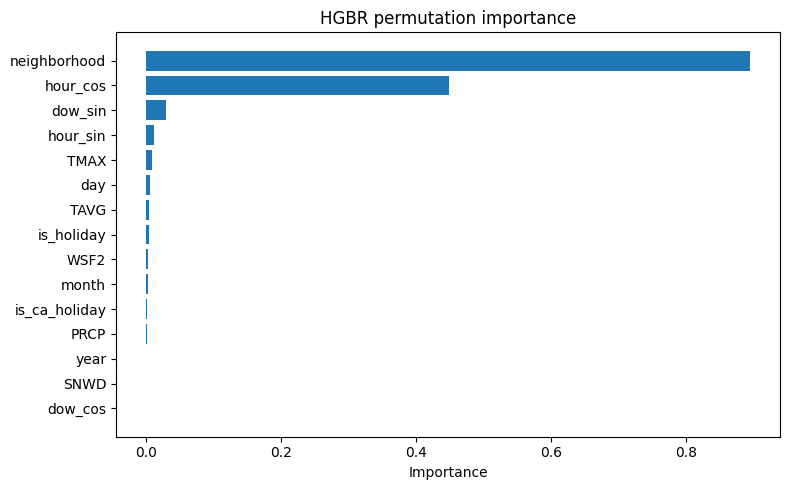

In [413]:
# Ridge
# ridge_imp = linear_feature_importance(ridge)
# plot_feature_importance(ridge_imp, "importance", "Ridge feature importance")

from sklearn.inspection import PartialDependenceDisplay

# HGBR
hgbr_imp = hgbr_permutation_importance(hgbr, X_test, y_test)
plot_feature_importance(hgbr_imp, "importance_mean", "HGBR permutation importance")

## GridsearchCV

In [ ]:
hgbr = make_hgbr_pipeline(feature_spec)
hgbr.named_steps.keys()

In [ ]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error

tscv = TimeSeriesSplit(n_splits=5)

hgbr_param_grid = {
    "model__learning_rate": [0.03, 0.06, 0.1],
    "model__max_depth": [3, 5, None],            # None allows leaf_nodes to drive complexity
    "model__min_samples_leaf": [10, 30, 80],
    # Optional (only if your sklearn version supports it for HGBR):
    # "model__max_leaf_nodes": [15, 31, 63],
}


In [ ]:
def tune_and_evaluate_hgbr(
    *,
    hgbr_pipe,
    X_train,
    y_train,
    X_test,
    y_test,
    param_grid,
    cv,
    category: str,
    store: MetricsStore,
    model_label: str = "HistGradientBoostingRegressor (tuned)",
) -> tuple[object, dict, float, float]:
    """
    Grid-search HGBR using TimeSeriesSplit on the train set, then evaluate on test set.
    Logs final train/test metrics into MetricsStore under model_label.
    Returns (best_estimator, best_params, cv_rmse, test_rmse).
    """
    gs = GridSearchCV(
        estimator=hgbr_pipe,
        param_grid=param_grid,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        refit=True,
    )

    gs.fit(X_train, y_train)

    best = gs.best_estimator_
    best_params = gs.best_params_

    # CV RMSE (convert sign)
    cv_rmse = -float(gs.best_score_)

    # Evaluate train/test RMSE (and the rest) using your existing store logger
    evaluate_model(
        model_label,
        best,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        store=store,
        category=category,
    )

    # Extra: explicit test RMSE if you want it returned too
    y_pred_test = best.predict(X_test)
    test_rmse = float(mean_squared_error(y_test, y_pred_test, multioutput='raw_values'))

    return best, best_params, cv_rmse, test_rmse


In [ ]:
store = MetricsStore()

best_params_by_cat = {}   # keep tuned params per category (for your writeup)

# for cat in CATEGORIES[:2]:
for cat in CATEGORIES:
    print(f"\n=== CATEGORY: {cat} ===")

    feat_df, train_df, test_df, X_train, y_train, X_test, y_test = new_make_splits_for_category(
        sf_dataframe,
        category=cat,
        neighborhoods=NEIGHBORHOODS,
        start=START,
        end=END,
        freq=FREQ,
        test_size=TEST_SIZE,
        feature_cols=feature_cols,
    )
    # --- DEBUG: prove what data we’re training on (add ONLY this block) ---
    print(f"\nDEBUG category loop value: {cat}")
    
    # if these dfs include a category column, this is the smoking gun
    if "category" in train_df.columns:
        print("train_df categories:", train_df["category"].value_counts().head(5).to_dict())
    if "category" in test_df.columns:
        print("test_df categories:", test_df["category"].value_counts().head(5).to_dict())
    
    print("n_train:", len(y_train), "n_test:", len(y_test))
    print("y_train mean/std:", float(y_train.mean()), float(y_train.std()))
    print("y_test  mean/std:", float(y_test.mean()), float(y_test.std()))
    # ---------------------------------------------------------------




    # Models
    dummy = make_dummy_pipeline("mean")
    hgbr  = make_hgbr_pipeline(feature_spec)

    # Baselines
    evaluate_model(
        "DummyRegressor(mean)",
        dummy,
        X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test,
        store=store, category=cat
    )

    evaluate_model(
        "HistGradientBoostingRegressor",
        hgbr,
        X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test,
        store=store, category=cat
    )

    # Tuned HGBR (GridSearchCV with TimeSeriesSplit)
    best_model, best_params, cv_rmse, test_rmse = tune_and_evaluate_hgbr(
        hgbr_pipe=hgbr,
        X_train=X_train, y_train=y_train,
        X_test=X_test, y_test=y_test,
        param_grid=hgbr_param_grid,
        cv=tscv,
        category=cat,
        store=store,
        model_label="HistGradientBoostingRegressor (tuned)",
    )

    best_params_by_cat[cat] = {
        "best_params": best_params,
        "cv_rmse": cv_rmse,
        "test_rmse": test_rmse,
    }


        # build viz df for THIS category
    viz_df = test_df[["interval_start", "neighborhood"]].copy()
    viz_df["y_true"] = y_test.to_numpy()
    viz_df["y_pred"] = best_model.predict(X_test)

    for nhood in viz_df["neighborhood"].unique():
        sub = viz_df[viz_df["neighborhood"] == nhood]

        plt.figure(figsize=(12, 4))
        plt.plot(sub["interval_start"], sub["y_true"], label="Observed")
        plt.plot(sub["interval_start"], sub["y_pred"], label="Predicted")
        plt.title(f"{cat} – {nhood}")
        plt.legend()
        plt.show()
        
results_df = store.to_frame()
results_df


In [ ]:
# View Tuned Parameters

pd.DataFrame.from_dict(best_params_by_cat, orient="index")

In [ ]:
best_params

In [ ]:
best_params_by_cat

In [ ]:
viz_df = test_df[["interval_start", "neighborhood"]].copy()
viz_df["y_true"] = y_test.to_numpy()
viz_df["y_pred"] = best_model.predict(X_test)
viz_df = viz_df.sort_values("interval_start")


## Visualize Predicted vs. Observed Data

In [ ]:
# Time-series pots per neighborhood
for nhood in viz_df["neighborhood"].unique():
    sub = viz_df[viz_df["neighborhood"] == nhood]

    plt.figure(figsize=(12, 4))
    plt.plot(sub["interval_start"], sub["y_true"], label="Observed", alpha=0.8)
    plt.plot(sub["interval_start"], sub["y_pred"], label="Predicted", alpha=0.8)

    plt.title(f"{cat} – {nhood}")
    plt.xlabel("Time")
    plt.ylabel("Event count (6-hour interval)")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(viz_df["y_true"], viz_df["y_pred"], alpha=0.3)
max_val = max(viz_df["y_true"].max(), viz_df["y_pred"].max())
plt.plot([0, max_val], [0, max_val], "--", color="black")
plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.title(f"{cat} – Predicted vs Observed")
plt.tight_layout()
plt.show()


In [ ]:
viz_df["residual"] = viz_df["y_true"] - viz_df["y_pred"]

plt.figure(figsize=(12, 4))
plt.plot(viz_df["interval_start"], viz_df["residual"], alpha=0.6)
plt.axhline(0, linestyle="--", color="black")
plt.title(f"{cat} – Residuals over time")
plt.xlabel("Time")
plt.ylabel("Residual (Observed − Predicted)")
plt.tight_layout()
plt.show()


In [ ]:
# hgbr.named_steps.keys()
hgbr.get_params().keys()

In [ ]:
print("cat:", cat, "| train rows:", len(X_train), "| test rows:", len(X_test))
print("y_train mean/std:", float(y_train.mean()), float(y_train.std()))
print("y_test  mean/std:", float(y_test.mean()), float(y_test.std()))


In [ ]:
fig, ax = plt.subplots(1,1)
#     # build viz df for THIS category
# viz_df = test_df[["interval_start", "neighborhood"]].copy()
# viz_df["y_true"] = y_test.to_numpy()
_ = ax.hist(
    best_model.predict(X_test),
    bins=100,
    label="predictions",
    density=True
)

test_df["count"].hist(bins=100, label="actual_data", density=True)
ax.legend()

# Study Permutation Feature Importance

## Data Loading and Feature Engineering

https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance.html

In [354]:
import numpy as np

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

X, y = fetch_openml("titanic", version=1, as_frame=True, return_X_y=True)
rng = np.random.RandomState(seed=42)
X["random_cat"] = rng.randint(3, size=X.shape[0]) # Low cordinality cat var (3 possible values)
X["random_num"] = rng.randn(X.shape[0]) # High cardinality numeric var (As many unique values as records)

categorical_columns = ["pclass", "sex", "embarked", "random_cat"]
numerical_columns = ["age", "sibsp", "parch", "fare", "random_num"]

X = X[categorical_columns + numerical_columns]
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

Define predictive model based on random forest. 
* Use `OrdinalEncoder` to encode categorical features
* Use `Simple Imputer` to fill missing values for numerical features using a mean strategy.

In [355]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

categorical_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value", unknown_value=-1, encoded_missing_value=-1
)
numerical_pipe = SimpleImputer(strategy="mean")

preprocessing = ColumnTransformer(
    [
        ("cat", categorical_encoder, categorical_columns),
        ("num", numerical_pipe, numerical_columns),
    ],
    verbose_feature_names_out=False,
)

rf = Pipeline(
    [
        ("preprocess", preprocessing),
        ("classifier", RandomForestClassifier(random_state=42)),
    ]
)
rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

## Accuracy of the Model

In [356]:
print(f"RF train accuracy: {rf.score(X_train, y_train):.3f}")
print(f"RF test accuracy: {rf.score(X_test, y_test):.3f}")

RF train accuracy: 1.000
RF test accuracy: 0.814


Here, one can observe that the train accuracy is very high (the forest model has enough capacity to completely memorize the training set) but it can still generalize well enough to the test set thanks to the built-in bagging of random forests.

It might be possible to trade some accuracy on the training set for a slightly better accuracy on the test set by limiting the capacity of the trees (for instance by setting min_samples_leaf=5 or min_samples_leaf=10) so as to limit overfitting while not introducing too much underfitting.

However, let us keep our high capacity random forest model for now so that we can illustrate some pitfalls about feature importance on variables with many unique values.

## Tree's Feature Importance from Mean Decrease in Impurity

Impurity-based importances are biased towards high cardinality features; so the "junk" column we added is highly important!

In [357]:
import pandas as pd

feature_names = rf[:-1].get_feature_names_out()

mdi_importances = pd.Series(
    rf[-1].feature_importances_, index=feature_names
).sort_values(ascending=True)

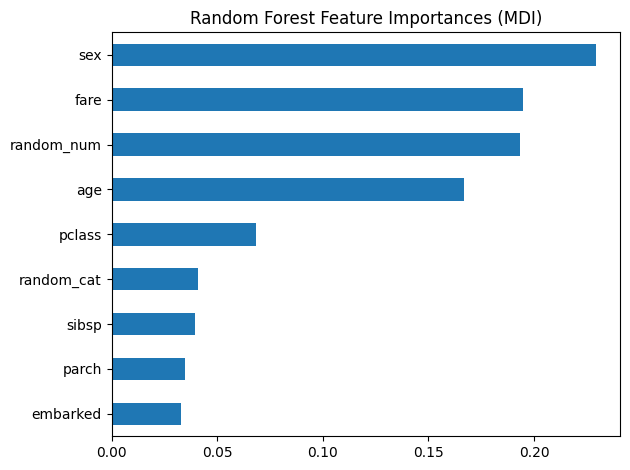

In [358]:
ax = mdi_importances.plot.barh()
ax.set_title("Random Forest Feature Importances (MDI)")
ax.figure.tight_layout()

As an alternative, the permutation importances of rf are computed on a held out test set. This shows that the low cardinality categorical feature, sex and pclass are the most important features. Indeed, permuting the values of these features will lead to the most decrease in accuracy score of the model on the test set.

Also, note that both random features have very low importances (close to 0) as expected.

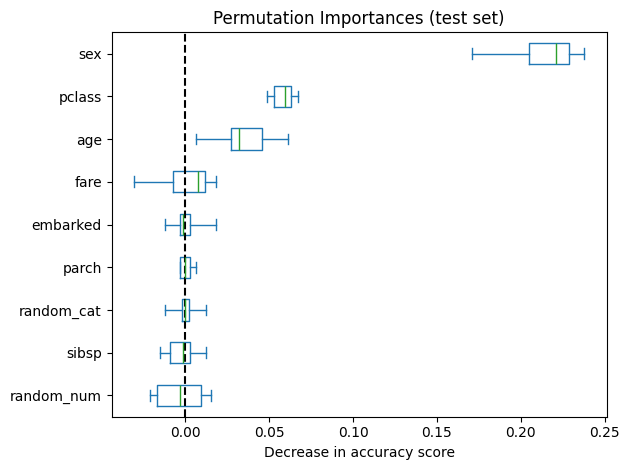

In [359]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X.columns[sorted_importances_idx],
)
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()

It is also possible to compute the permutation importances on the training set. This reveals that random_num and random_cat get a significantly higher importance ranking than when computed on the test set. The difference between those two plots is a confirmation that the RF model has enough capacity to use that random numerical and categorical features to overfit.

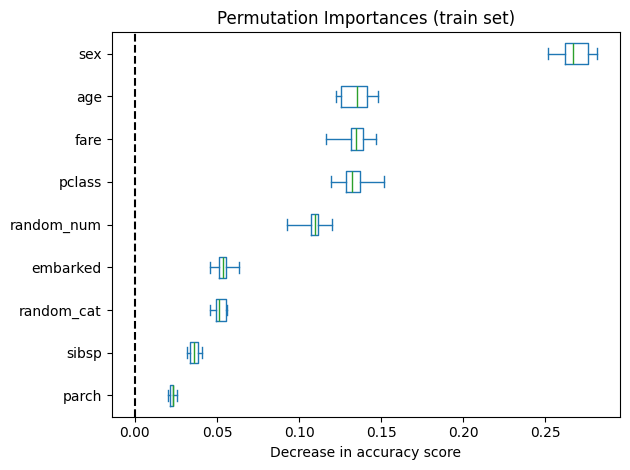

In [360]:
result = permutation_importance(
    rf, X_train, y_train, n_repeats=10, random_state=42, n_jobs=2
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X.columns[sorted_importances_idx],
)
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (train set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()

In [361]:
rf.set_params(classifier__min_samples_leaf=20).fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

In [362]:
print(f"RF train accuracy: {rf.score(X_train, y_train):.3f}")
print(f"RF test accuracy: {rf.score(X_test, y_test):.3f}")

RF train accuracy: 0.810
RF test accuracy: 0.832


In [363]:
train_result = permutation_importance(
    rf, X_train, y_train, n_repeats=10, random_state=42, n_jobs=2
)
test_results = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)
sorted_importances_idx = train_result.importances_mean.argsort()

In [364]:
train_importances = pd.DataFrame(
    train_result.importances[sorted_importances_idx].T,
    columns=X.columns[sorted_importances_idx],
)
test_importances = pd.DataFrame(
    test_results.importances[sorted_importances_idx].T,
    columns=X.columns[sorted_importances_idx],
)

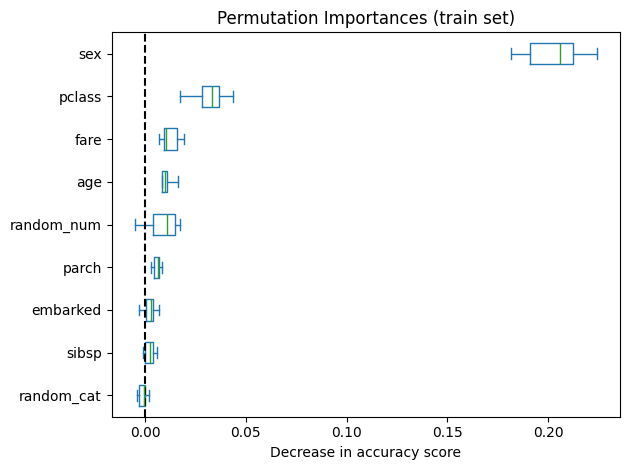

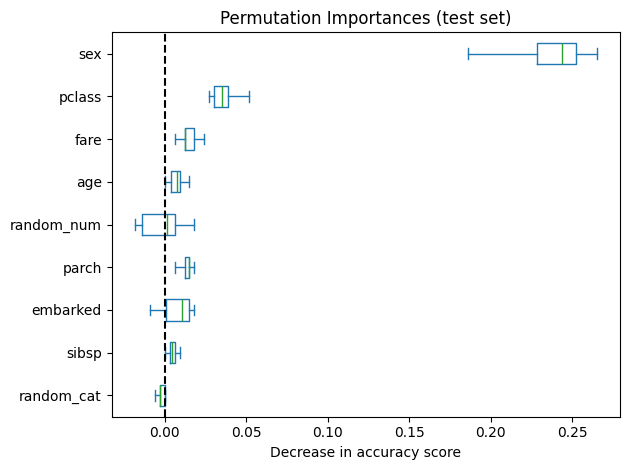

In [365]:
for name, importances in zip(["train", "test"], [train_importances, test_importances]):
    ax = importances.plot.box(vert=False, whis=10)
    ax.set_title(f"Permutation Importances ({name} set)")
    ax.set_xlabel("Decrease in accuracy score")
    ax.axvline(x=0, color="k", linestyle="--")
    ax.figure.tight_layout()

In [368]:
result

{'importances_mean': array([0.13312946, 0.26788991, 0.05382263, 0.05158002, 0.13465851,
        0.03618756, 0.02273191, 0.13455657, 0.10897044]),
 'importances_std': array([0.00937819, 0.00938483, 0.00446199, 0.0036527 , 0.00917941,
        0.00326357, 0.00164684, 0.00881621, 0.00760711]),
 'importances': array([[0.12130479, 0.15188583, 0.14475025, 0.11926606, 0.13251784,
         0.13455657, 0.12844037, 0.13761468, 0.13149847, 0.12945973],
        [0.26911315, 0.2579001 , 0.26197757, 0.28134557, 0.27217125,
         0.27726809, 0.25178389, 0.26197757, 0.26503568, 0.2803262 ],
        [0.05606524, 0.06320082, 0.05300714, 0.05300714, 0.05810398,
         0.04994903, 0.04587156, 0.0540265 , 0.0540265 , 0.0509684 ],
        [0.0540265 , 0.05606524, 0.04994903, 0.04892966, 0.05198777,
         0.04689093, 0.04587156, 0.04994903, 0.05606524, 0.05606524],
        [0.1243629 , 0.12538226, 0.12232416, 0.12640163, 0.13965341,
         0.14780836, 0.14169215, 0.14780836, 0.13353721, 0.13761468],

# HGBR Partial Dependency

In [369]:
hgbr_imp

,feature,importance_mean,importance_std
0,neighborhood,0.893821,0.019810
1,hour_cos,0.448660,0.010540
2,dow_sin,0.029359,0.003295
3,hour_sin,0.011959,0.002902
4,TMAX,0.007707,0.002421
5,day,0.004971,0.002359
6,TAVG,0.004484,0.001895
7,is_holiday,0.003837,0.001021
8,WSF2,0.003245,0.001088
9,month,0.002948,0.001040


In [415]:
# Keep only *raw* input columns (the ones actually in X_test)
top_features = (
    hgbr_imp.loc[hgbr_imp["feature"].isin(X_test.columns)]
           .sort_values("importance_mean", ascending=False)
           .head(5)["feature"]
           .tolist()
)

top_features

['neighborhood', 'hour_cos', 'dow_sin', 'hour_sin', 'TMAX']

In [417]:
# keep only numeric columns for PDP
numeric_cols = X_test.select_dtypes(include=[np.number, "bool"]).columns
pdp_features = [f for f in top_features if f in numeric_cols]

pdp_features

['hour_cos', 'dow_sin', 'hour_sin', 'TMAX']

In [ ]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# optional: sample for speed
X_for_pdp = X_test.sample(n=min(5000, len(X_test)), random_state=0)

PartialDependenceDisplay.from_estimator(
    best_model,          # <- tuned + fitted pipeline
    X_for_pdp,           # <- raw DataFrame with column names
    features=pdp_features,
    kind="average",      # PDP only
    grid_resolution=50,
    n_cols=2,
)

plt.suptitle(f"PDPs — {cat} — tuned HGBR", y=1.02)
# plt.tight_layout()
plt.show()

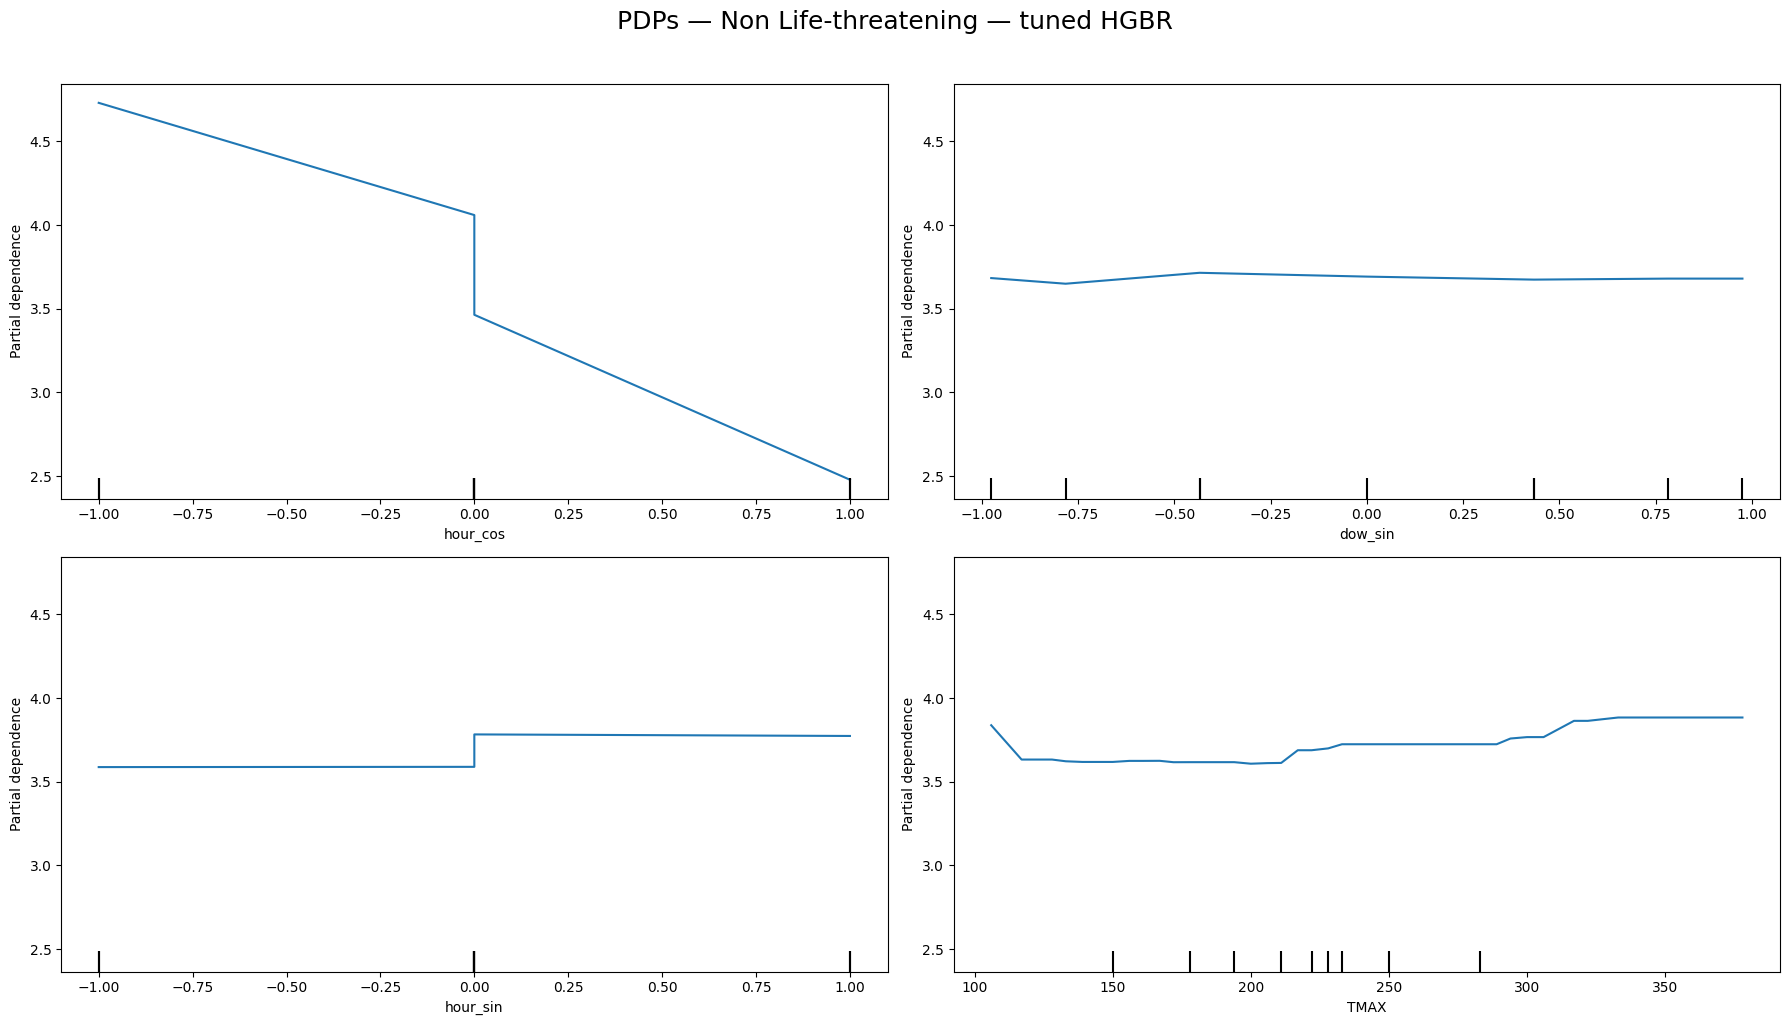

In [422]:
import math
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

features = pdp_features          # list of feature names you want PDPs for
n_cols = 2
n_rows = math.ceil(len(features) / n_cols)

fig, ax = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
ax = ax.ravel()  # flatten to 1D array of axes

PartialDependenceDisplay.from_estimator(
    best_model,
    X_for_pdp,
    features=features,
    kind="average",
    grid_resolution=50,
    ax=ax[: len(features)],       # <-- give sklearn EXACTLY the right number
)

# hide any unused axes
for j in range(len(features), len(ax)):
    ax[j].set_visible(False)

fig.suptitle(f"PDPs — {cat} — tuned HGBR", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

**hour_cos** — Time of day effect: Encodes the time of day cyclically

Values near:
* -1 → early morning / late night
* 0 → midday / midnight transition
* +1 → afternoon / evening

What the plot shows

* Higher predicted counts at early hours
* Clear drop around the midpoint (≈ mid-day)
* Lower predicted counts later in the day

The model predicts more non-life-threatening incidents during early hours of the day, with activity decreasing as the day progresses. Early-day activity, reporting patterns, or service workflows may drive this.

**dow_sin** — Day-of-week effect: Encodes the day of the week cyclically
Prevents Monday and Sunday from being treated as “far apart”

Nearly flat line. Very small variation across days. The model does not strongly differentiate between days of the week for this category.

Day-of-week is not very predictive. Weekdays vs weekends don’t matter much here. 

**hour_sin** — Another time-of-day angle

* A step-like increase around the zero crossing

Fairly flat otherwise. The model sees a slight increase in predicted events during a specific time window, but overall time-of-day effects are modest.

**TMAX** — Maximum daily temperature

Gradual upward slope. Higher predicted counts on hotter days. The model predicts more non-life-threatening incidents on hotter days. This tracks with heightened foot traffic, exposure to elements, and likely larger amounts of citizens.

* More people outside
* More activity
* More interactions with public space

Partial dependence plots show that time-of-day and temperature are the strongest drivers of predicted non-life-threatening events. The model predicts higher activity during early hours and on hotter days, while day-of-week effects appear minimal. This suggests that temporal patterns within a day and environmental conditions play a larger role than weekly cycles for this category.

## ICE Plots

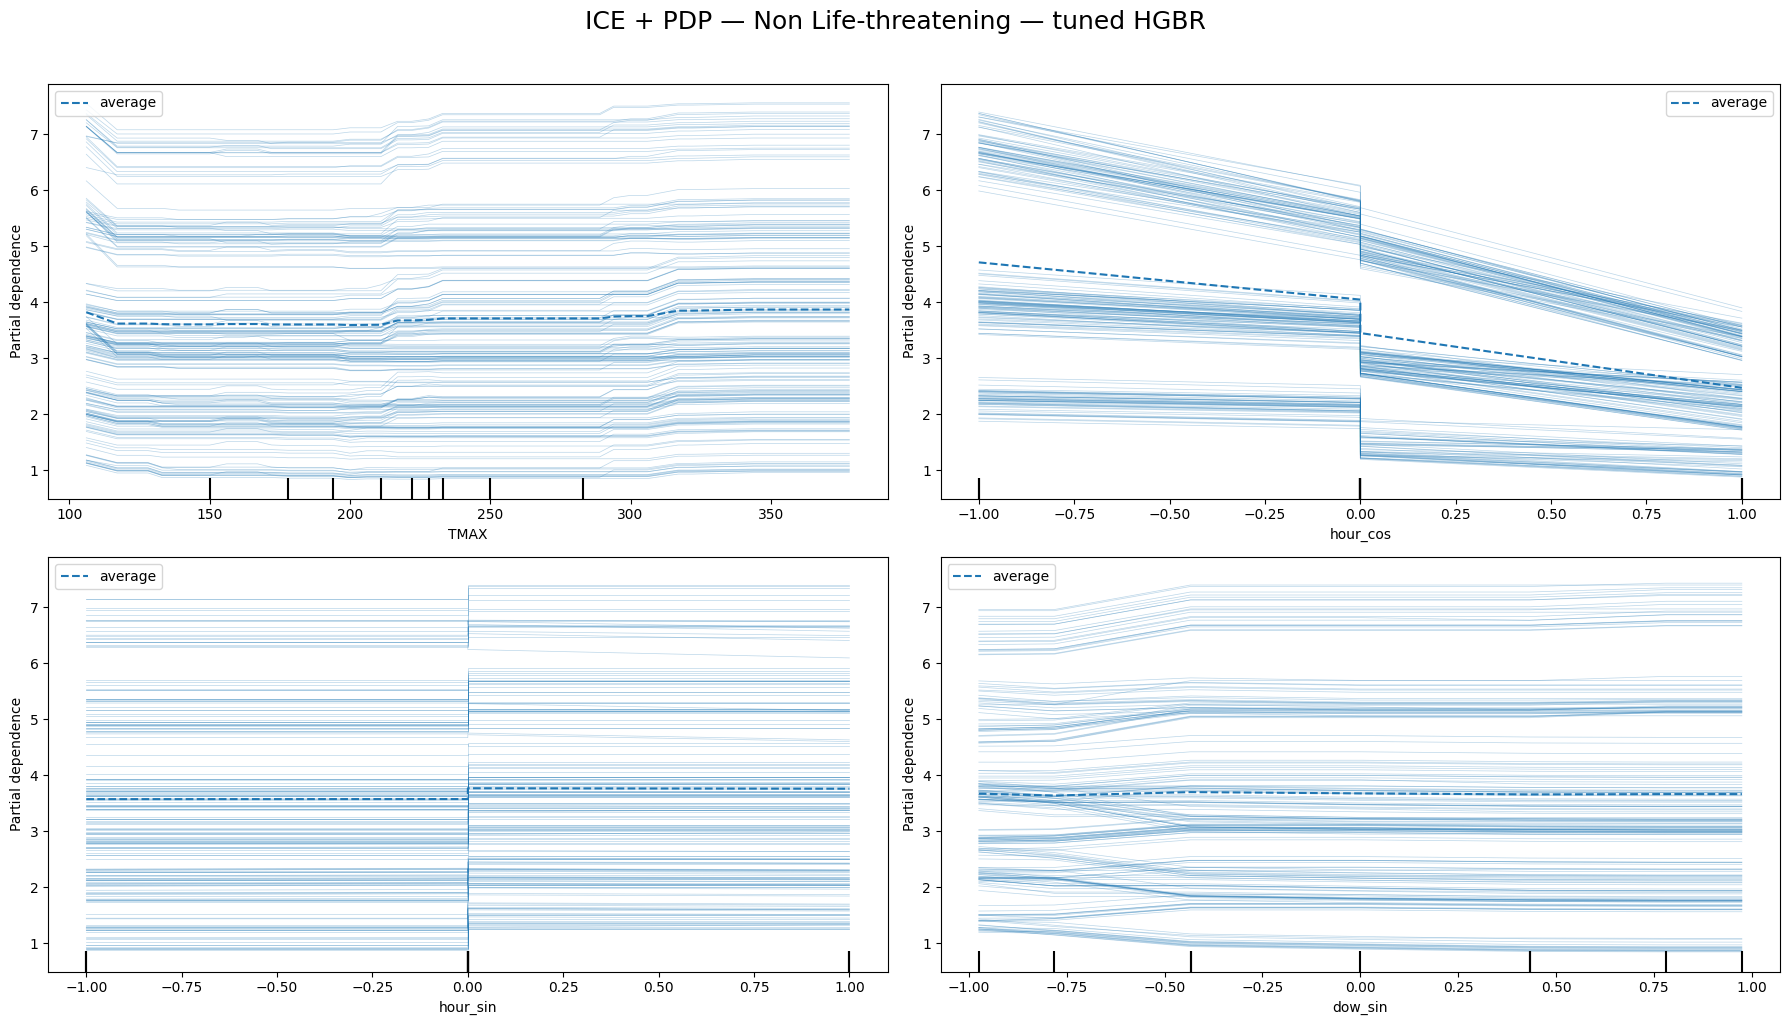

In [423]:
# Choose features (numeric only is easiest to interpret)
ice_features = ["TMAX", "hour_cos", "hour_sin", "dow_sin"]  # edit as needed

# Sample for speed + readability
X_for_ice = X_test.sample(n=min(800, len(X_test)), random_state=0)

n_cols = 2
n_rows = math.ceil(len(ice_features) / n_cols)

fig, ax = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
ax = ax.ravel()

PartialDependenceDisplay.from_estimator(
    best_model,                 # tuned + fitted pipeline
    X_for_ice,                  # raw DataFrame
    features=ice_features,
    kind="both",                # PDP + ICE
    subsample=200,              # how many ICE lines to draw (keeps it readable)
    grid_resolution=50,
    random_state=0,
    ax=ax[: len(ice_features)],
)

# Hide unused axes
for j in range(len(ice_features), len(ax)):
    ax[j].set_visible(False)

fig.suptitle(f"ICE + PDP — {cat} — tuned HGBR", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()


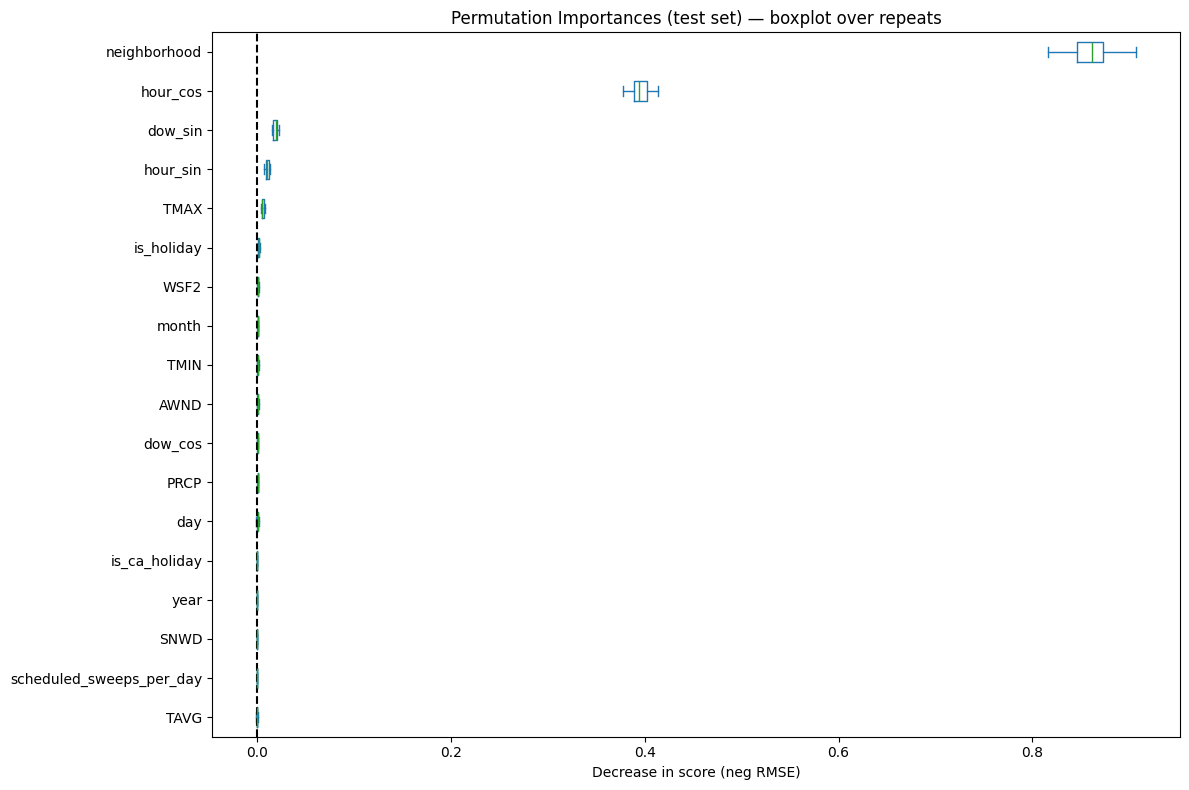

In [424]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# best_model is your fitted pipeline (e.g., tuned HGBR pipeline)
# X_test is your raw DataFrame, y_test is your target array/Series

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
    scoring="neg_root_mean_squared_error",  # for regression; matches what you used earlier
)

# IMPORTANT:
# perm.importances shape: (n_features, n_repeats)
# feature names must correspond to WHAT permutation_importance permutes.
# If you're permuting raw columns, use X_test.columns.
feature_names = list(X_test.columns)

# Sort features by mean importance
sorted_idx = np.argsort(perm.importances_mean)

# Build a DataFrame of per-repeat importances for boxplots
# shape becomes (n_repeats, n_features)
imp_df = pd.DataFrame(
    perm.importances[sorted_idx].T,
    columns=np.array(feature_names)[sorted_idx],
)

ax = imp_df.plot.box(vert=False, whis=10, figsize=(12, 8))
ax.set_title("Permutation Importances (test set) — boxplot over repeats")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in score (neg RMSE)")
plt.tight_layout()
plt.show()


# Fairness Questions

_*How can we ensure it won’t lead to unfair or discriminatory handling?*_

Think of this as: don’t let the model become an automated excuse to treat places/people differently without checks.

**Concrete Model Safeguards:**

1. Use the model as decision support, not an automatic dispatcher
* Human-in-the-loop for high-impact decisions
* Require operators to record a reason when overriding (creates audit trail)

2. Separate “prediction” from “policy”
* Prediction: “expected event volume”
* Policy: “how we allocate resources”
* Policies should encode fairness constraints explicitly (e.g., minimum service levels)

3. Audit outcomes regularly
* Compare response times / service levels across neighborhoods before vs after deployment
* Flag if some areas consistently get worse outcomes because of model-driven allocation

4. Monitor drift and retrain responsibly
* The city changes; reporting changes; enforcement changes
* Use monitoring to detect when the model stops matching reality (data drift / concept drift)

5. Transparency
* Publish a simple model card: what data, what it predicts, what it does not do, known limitations

**Possible biases in training data (and sensitive features/categories)**

_Big idea_: 311/911-type data often reflects reporting behavior and enforcement, not just “true underlying events.”

Common bias sources here:
1. Reporting bias

* Some neighborhoods report more (access, trust, language, knowledge of 311, time availability)
* Some problems are underreported due to fear, stigma, or low trust in services

2. Enforcement / service bias
* If city services historically patrol/enforce more in certain areas, you get more recorded incidents there
* The model learns “where the city tends to act,” not necessarily “where need is highest”

3. Data quality bias
* Missing/unknown neighborhood, mis-geocoding, inconsistent categories over time
* Changing definitions of categories (policy shifts) create non-stationary labels

_Sensitive features (in your setup):_

* neighborhood is the big one. It’s not inherently “protected,” but it is often a proxy for
* socioeconomic status, race/ethnicity composition, housing instability, etc.
* External features like “encampment schedules,” enforcement actions, etc., can also be proxy-ish.

_Sensitive event categories (context-dependent):_
* “Encampments” is the obvious one (high risk of stigmatization and policy enforcement coupling).
* Anything that tracks vulnerable populations or could trigger differential enforcement deserves extra scrutiny.

**Cost of errors in practice**

Your model predicts counts, so errors mostly become resource allocation mistakes.
1. Under-prediction (false low)
* Not enough staff/resources
* Longer response times, missed cleanings, slower hazard mitigation
* This is usually the more harmful error for safety-critical categories

2. Over-prediction (false high)
* Over-allocation of crews/response capacity
* Opportunity cost: other neighborhoods/categories get fewer resources
* Budget inefficiency

_How to “price” errors:_
* Use an asymmetric cost mindset: for safety categories, treat under-prediction as more expensive
* Operationally: “If we’re wrong, which direction hurts more?” and bias the decision rules accordingly
(even if the model is unbiased, the policy can be conservative).

**Risk of feedback loops**

Yes, feedback loops are plausible here.

A feedback loop looks like:
1. Model predicts “more events” in Neighborhood A
2. City allocates more crews / enforcement / attention to A
3. That leads to more observed reports/records in A (because there’s more presence, detection, or easier reporting)
4. Next training cycle, the model sees even higher counts in A
→ reinforcing cycle

This is especially likely for:

* Encampments
* Anything tied to enforcement or city presence
* Any category where “measurement” increases with “attention”

Mitigations:

* Track not just counts, but service presence (crew hours, patrol hours) as an input and/or control variable
* Use holdout evaluation by time (you did) and re-check after deployment
* Consider retraining with policies that avoid using “post-allocation” data naïvely
* Keep a “shadow mode” period: run model, don’t act on it, compare predictions vs reality before using it to allocate resources


Because reporting and enforcement can change in response to resource allocation, model-driven decisions may create feedback loops that alter future data distributions; this requires monitoring and governance. "Broken Windows" enabled by data